# **Data Mining Project - Mental Health in Tech Survey**

##### Authors: Xiaoyan Li s201292, Maria Porębska s198113, Wiktoria Kopciał s197774  
##### Date:

## **Part II: Data Preparation + Modeling**

### **General Description of the Dataset**  
The *Mental Health in Tech Survey* dataset is holding the results of the survey conducted in 2014 in order to measure attitudes towards mental health and frequency of mental health disorders in the tech workplace. The survey collected data from respondents worldwide.

### **Quick Review of Data Mining Goals and Success Criteria**

#### Data mining goals:

The goal is to understand how certain factors influence mental health and people’s attitude toward it. In particular, we want to analyze how work life impacts mental health. We also aim to predict what kinds of people are more likely to seek mental health treatment and in which countries the organizations are the most opened to discussing mental health issues.

#### Succes criteria:

Success will be measured by the ability:
* to find at least 5 statistically significant patterns (p < 0.05) in the data (which factors are associated with mental health outcomes or attitudes);
* to build a prediction model for treatment-seeking behavior that achieves an accuracy of at least 70%;
* to identify significant country-level differences in mental health openness with at least 3 countries showing statistically significant variance (p < 0.05)

### **Data Mining Task & Modeling Algorithm & Evaluation Method**

Based on our goals, we need to find statistically significant patterns and country-level openness differences, as well as predict likelihood of treatment-seeking behavior.

Therefore we have **two tasks**:
*   Descriptive data mining (e.g. correlation analysis, association rules, group comparison)
*   Predictive modeling (classification)

For prediction of treatment-seeking behavior, we can use the following **modeling algorithms**:
* Decision Tree (e.g. CART / C4.5) → easily interpretable
* Random Forest → more accurate, handles missing data better
* Optionally test: Logistic Regression, Support Vector Machine (SVM)

For finding country-level openness differences, following **methods** are used:
* Decision Tree
* Random Forest
* Clustering
* Chi-square test - test for variance

Since it's a classification task with a 70% accuracy threshold, we can split the data and choose one or more of the following **evaluation methods**:
* Train/test split (e.g. 80/20)
* Use 10-fold cross-validation for more stable results

Evaluation metrics:
* Accuracy
* Confusion Matrix
* Precision / Recall / F1-Score (in case of imbalance)
* Check statistical significance (p-values) for pattern discovery tasks.

### **Data Preparation**

The dataset has **missing values** for the following attributes: state, self-employed, work_interfere and comments.

**State:** The missing values obviously appear in the dataset due to the fact that some people don't live in the U.S., so we counted the amount of people living elswhere and compared it to number of missing values. For people living outside of U.S, we swapped the NaN values to "Not living in U.S", for additional respondents, who live in U.S, but didn't specify their state, we decided to change the missing values to "Unknown state".

**Self-employed:** Here we also keep missing values, but just change them to "Unknown", because we can't verify the reason why some respondents skip this question.

**Work_interfere:** Here we keep missing values, but change them to "Not applicable/Unknown", because we assume that most respondents skip this question since they don't have a mental health condition (Not applicable), but we can't check if that's the reason for all respondents (Unknown).

**Comments:** We drop all the missing comments as we only want to analyze the responses that include some text.

The dataset also has some noticeable **outliers**, especially in the **Age** and **Gender** attributes during the analysis.

**Age:** The outliers are extreme values that fall outside the expected range of ages, such as negative values, positive yet very small values or values greater than 100 years. These outliers may indicate data entry errors or respondents who either don't fit the profile of the target population (e.g., age values like 5 or 8) or they don't want to disclose this information.

It is essential to address these outliers because they can skew the analysis, especially when calculating averages or distributions. We chose to clean the Age attribute by filtering for realistic values (ages between 18 and 100), leaving only valid data for further analysis.

**Gender:** There are a few instances of inconsistent or potentially erroneous entries. For example, in the Gender column, values like "M", "F", "mail" (a typo for "male"), and various capitalizations of "male" and "female" were found. These inconsistencies were addressed by standardizing the Gender values to a consistent set of categories: "male", "female", and "other". Such standardization is crucial for ensuring that categorical variables are properly grouped and analyzed.

Most of the attributes in the dataset are categorical, and for both Decision Tree and Random Forest we will use scikit-learn model, which requires numerical data for input - so we will convert from categorical to numerical data.
In terms of Logistic Regression / SVM, we need numeric encoding, so we might need to convert yes/no/unknown to binary.

### **Pattern Finding & Model Creation**


####Data load and correction from the first report

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
import scipy.stats as stats

# Download latest version
path = kagglehub.dataset_download("osmi/mental-health-in-tech-survey")

# Load the dataset
df = pd.read_csv(os.path.join(path, "survey.csv"))

#Age correction

# Replace obvious errors with NaN (if not a valid number)
df['Age_cleaned'] = pd.to_numeric(df['Age'], errors='coerce')

# Filter to keep only realistic ages (18 to 100)
df = df[(df['Age_cleaned'] >= 18) & (df['Age_cleaned'] <= 100)].copy()

Q1 = df['Age_cleaned'].quantile(0.25)
Q3 = df['Age_cleaned'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['Age_cleaned'] < lower_bound) | (df['Age_cleaned'] > upper_bound)]

# Define age ranges
bins = [18, 25, 35, 45, 60, 100]
labels = ['18-25', '26-35', '36-45', '46-60', '60+']

# Create a new column with the age group for cleaned data
df['Age_Group'] = pd.cut(df['Age_cleaned'], bins=bins, labels=labels, right=True)

# Count the number of people in each group
age_counts = df['Age_Group'].value_counts().sort_index()

# Gender correction

# Clean 'Gender' column
gender_mapping = {
    'male': 'male', 'm': 'male', 'mail': 'male', 'maile': 'male', 'man': 'male', 'mal': 'male',
    'female': 'female', 'f': 'female', 'femail': 'female', 'woman': 'female'
}

# Create a new 'Gender_cleaned' column with standardized values
df['Gender_cleaned'] = df['Gender'].str.lower().map(gender_mapping).fillna('other')

#Country correction

# Count the occurrences of each country
country_counts = df['Country'].value_counts()

# Keep top 10 countries and categorize others as 'Other'
top_countries = country_counts.head(10)
df['Country_category'] = df['Country'].apply(lambda x: x if x in top_countries.index else 'Other')

# Count the occurrences of the new 'Country_category' column
country_category_counts = df['Country_category'].value_counts()

# state correction

#filling all the previous missing values back to NaN, so we can count missing values
df['state'] = df['state'].replace('Not living in U.S.', np.nan)
df['state'] = df['state'].replace('Unknown State', np.nan)

#checking if the number of missing values in state is equal to the number of people not living in U.S
non_us_count = df[df['Country'] != 'United States'].shape[0]
missing_state_count = df['state'].isna().sum()

#changing missing values accordingly to if they live in U.S or not
df.loc[(df['Country'] != 'United States') & (df['state'].isna()), 'state'] = 'Not living in U.S.'
df.loc[(df['Country'] == 'United States') & (df['state'].isna()), 'state'] = 'Unknown State'

#filling missing values for self-employed attribute to Unknown
df['self_employed'] = df['self_employed'].fillna('Unknown')
#filling missing values for self-employed attribute to Not applicable/Unknown
df['work_interfere'] = df['work_interfere'].fillna('Not applicable/Unknown')

#comments

# Drop missing values in 'comments' column
comments = df['comments'].dropna()

# Quick look at the data
df.head()


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments,Age_cleaned,Age_Group,Gender_cleaned,Country_category
0,2014-08-27 11:29:31,37,Female,United States,IL,Unknown,No,Yes,Often,6-25,...,Yes,No,Maybe,Yes,No,NaN,37,36-45,female,United States
1,2014-08-27 11:29:37,44,M,United States,IN,Unknown,No,No,Rarely,More than 1000,...,No,No,No,Don't know,No,NaN,44,36-45,male,United States
2,2014-08-27 11:29:44,32,Male,Canada,Not living in U.S.,Unknown,No,No,Rarely,6-25,...,Yes,Yes,Yes,No,No,NaN,32,26-35,male,Canada
3,2014-08-27 11:29:46,31,Male,United Kingdom,Not living in U.S.,Unknown,Yes,Yes,Often,26-100,...,No,Maybe,Maybe,No,Yes,NaN,31,26-35,male,United Kingdom
4,2014-08-27 11:30:22,31,Male,United States,TX,Unknown,No,No,Never,100-500,...,Yes,Yes,Yes,Don't know,No,NaN,31,26-35,male,United States


###Finding 5 Significant Patterns

In [ ]:
# Perform Chi-Squared tests for categorical variables
categorical_pairs_to_check = [
    ('treatment', 'Gender_cleaned'),
    ('treatment', 'family_history'),
    ('treatment', 'work_interfere'),
    ('treatment', 'care_options'),
    ('benefits', 'no_employees'),
    ('wellness_program', 'no_employees'),
    ('seek_help', 'no_employees'),
    ('treatment', 'no_employees'),
    ('self_employed', 'no_employees'),
    ('care_options', 'benefits'),
    ('wellness_program', 'benefits'),
    ('seek_help', 'benefits'),
    ('seek_help', 'wellness_program'),
    ('mental_health_consequence', 'supervisor'),
    ('mental_health_consequence', 'phys_health_consequence'),
    ('mental_health_interview', 'phys_health_interview'),
    ('supervisor', 'coworkers')
]

chi_squared_results = []

print("Chi-Squared Test Results:")
for var1, var2 in categorical_pairs_to_check:
    contingency_table = pd.crosstab(df[var1], df[var2])
    chi2, p, dof, ex = stats.chi2_contingency(contingency_table)
    # Store results as a tuple (var1, var2, chi2, p)
    chi_squared_results.append((var1, var2, chi2, p))
    print(f"Relationship between {var1} and {var2}:")
    print(f"  Chi-Squared Statistic: {chi2:.4f}")
    print(f"  P-value: {p}")
    if p < 0.05:
        print("  Result: Statistically Significant")
    else:
        print("  Result: Not Statistically Significant")
    print("-" * 30)

Chi-Squared Test Results:
Relationship between treatment and Gender_cleaned:
  Chi-Squared Statistic: 50.8221
  P-value: 9.206901523717066e-12
  Result: Statistically Significant
------------------------------
Relationship between treatment and family_history:
  Chi-Squared Statistic: 175.9552
  P-value: 3.703610823400622e-40
  Result: Statistically Significant
------------------------------
Relationship between treatment and work_interfere:
  Chi-Squared Statistic: 587.5908
  P-value: 7.512869823108202e-126
  Result: Statistically Significant
------------------------------
Relationship between treatment and care_options:
  Chi-Squared Statistic: 92.9136
  P-value: 6.66909669045227e-21
  Result: Statistically Significant
------------------------------
Relationship between benefits and no_employees:
  Chi-Squared Statistic: 306.4866
  P-value: 6.607104481259455e-60
  Result: Statistically Significant
------------------------------
Relationship between wellness_program and no_employees:


In [ ]:
# Sort results by chi-squared statistic in descending order
sorted_results = sorted(chi_squared_results, key=lambda x: x[2], reverse=True)
# Select the top 5 significant patterns
top_5_significant = sorted_results[:5]

print("Top 5 Statistically Significant Patterns (based on Chi-Squared statistic):")
print("-" * 80)
for result in top_5_significant:
    # Access elements using integer indices
    print(f"Relationship between {result[0]} and {result[1]}:")
    print(f"  Chi-Squared Statistic: {result[2]:.4f}") # Display chi-squared for context
    print(f"  P-value: {result[3]}") # Access p-value using index 3
    print("-" * 30)

Top 5 Statistically Significant Patterns (based on Chi-Squared statistic):
--------------------------------------------------------------------------------
Relationship between seek_help and wellness_program:
  Chi-Squared Statistic: 700.7821
  P-value: 2.359847395414372e-150
------------------------------
Relationship between treatment and work_interfere:
  Chi-Squared Statistic: 587.5908
  P-value: 7.512869823108202e-126
------------------------------
Relationship between seek_help and benefits:
  Chi-Squared Statistic: 487.1618
  P-value: 4.004874241479987e-104
------------------------------
Relationship between supervisor and coworkers:
  Chi-Squared Statistic: 480.7525
  P-value: 9.741272187258393e-103
------------------------------
Relationship between mental_health_consequence and supervisor:
  Chi-Squared Statistic: 462.0327
  P-value: 1.087428795115554e-98
------------------------------


Based on the Chi-Squared test results, we can see the top 5 statistically significant patterns:

1. **Seeking Help and Wellness Programs:** There is a strong statistically significant relationship between whether individuals seek help for mental health issues and if their employer offers a wellness program. This suggests that the availability of wellness programs is associated with people being more likely to seek help.

2. **Treatment and Work Interference:** A highly significant pattern exists between receiving mental health treatment and the extent to which a mental health condition interferes with work. This indicates that individuals seeking or receiving treatment often experience some level of work interference due to their mental health.

3. **Seeking Help and Benefits:** The data shows a significant association between seeking mental health help and the benefits provided by the employer. This implies that the presence of mental health benefits influences whether employees seek help.

4. **Supervisor and Coworker Attitudes:** There's a notable relationship between how comfortable employees are discussing mental health with their supervisor and how comfortable they are discussing it with their coworkers. This suggests that workplace culture regarding mental health, as perceived through interactions with supervisors and colleagues, is interconnected.

5. **Mental Health Consequences and Supervisor Discussion:** The results indicate a statistically significant link between whether a mental health condition has negative consequences and the willingness to discuss mental health with a supervisor. This might suggest that experiencing negative consequences makes employees less likely to discuss it with their supervisor.

###Prediction model for treatment-seeking behavior

In [ ]:
#choosing work parameters for the algorithm

#we leave out timestamp and comments from the attributes as they won't help us
features = [
    'Age_cleaned', 'Gender_cleaned', 'Country_category', 'state',
    'self_employed', 'family_history', 'work_interfere', 'no_employees',
    'remote_work', 'tech_company','benefits', 'care_options',
    'wellness_program', 'seek_help', 'anonymity', 'leave',
    'mental_health_consequence', 'phys_health_consequence',
    'coworkers', 'supervisor', 'mental_health_interview',
    'phys_health_interview','mental_vs_physical', 'obs_consequence'
]

#combining the needed features with the target variable -> treatment
model_df = df[features + ['treatment']].copy()

#Converting from categorical to numerical data
gender_map = {'male': 1, 'female': 0, 'other': 2}
model_df['Gender_cleaned'] = model_df['Gender_cleaned'].map(gender_map)
country_map = {'United States': 0, 'United Kingdom': 1, 'Canada': 2, 'Germany': 3, 'Ireland': 4, 'Netherlands': 5, 'Australia': 6, 'France': 7,
               'India': 8, 'New Zealand': 9, 'Other': 10}
model_df['Country_category'] = model_df['Country_category'].map(country_map)
state_map = {
    'AL': 0, 'AK': 1, 'AZ': 2, 'AR': 3, 'CA': 4, 'CO': 5, 'CT': 6, 'DE': 7, 'FL': 8, 'GA': 9,
    'HI': 10, 'ID': 11, 'IL': 12, 'IN': 13, 'IA': 14, 'KS': 15, 'KY': 16, 'LA': 17, 'ME': 18, 'MD': 19,
    'MA': 20, 'MI': 21, 'MN': 22, 'MS': 23, 'MO': 24, 'MT': 25, 'NE': 26, 'NV': 27, 'NH': 28, 'NJ': 29,
    'NM': 30, 'NY': 31, 'NC': 32, 'ND': 33, 'OH': 34, 'OK': 35, 'OR': 36, 'PA': 37, 'RI': 38, 'SC': 39,
    'SD': 40, 'TN': 41, 'TX': 42, 'UT': 43, 'VT': 44, 'VA': 45, 'WA': 46, 'WV': 47, 'WI': 48, 'WY': 49,
    'Not living in U.S.': 50,
    'Unknown State': 51
}
model_df['state'] = model_df['state'].map(state_map)
self_employed_map = {'Yes': 1, 'No': 0, 'Unknown': 2}
model_df['self_employed'] = model_df['self_employed'].map(self_employed_map)
model_df['family_history'] = model_df['family_history'].apply(lambda x: 1 if x == 'Yes' else 0)
work_interfere_map = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Not applicable/Unknown': 4}
model_df['work_interfere'] = model_df['work_interfere'].map(work_interfere_map)
no_employees_map = {'1-5': 1, '6-25': 2, '26-100': 3, '100-500': 4, '500-1000': 5, 'More than 1000': 6}
model_df['no_employees'] = model_df['no_employees'].map(no_employees_map)
model_df['remote_work'] = model_df['remote_work'].apply(lambda x: 1 if x == 'Yes' else 0)
model_df['tech_company'] = model_df['tech_company'].apply(lambda x: 1 if x == 'Yes' else 0)
yes_no_dk_map = {'Yes': 1, 'No': 0, "Don't know" : 2}
model_df['benefits'] = model_df['benefits'].map(yes_no_dk_map)
yes_no_notsure_map = {'Yes': 1, 'No': 0, "Not sure" : 2}
model_df['care_options'] = model_df['care_options'].map(yes_no_notsure_map)
model_df['wellness_program'] = model_df['wellness_program'].map(yes_no_dk_map)
model_df['seek_help'] = model_df['seek_help'].map(yes_no_dk_map)
model_df['anonymity'] = model_df['anonymity'].map(yes_no_dk_map)
leave_map = {'Very difficult': 0, 'Somewhat difficult': 1, 'Somewhat easy': 2, 'Very easy': 3, "Don't know": 4}
model_df['leave'] = model_df['leave'].map(leave_map)
yes_no_maybe_map = {'Yes': 1, 'No': 0, "Maybe" : 2}
model_df['mental_health_consequence'] = model_df['mental_health_consequence'].map(yes_no_maybe_map)
model_df['phys_health_consequence'] = model_df['phys_health_consequence'].map(yes_no_maybe_map)
yes_no_some_map = {'Yes': 1, 'No': 0, "Some of them" : 2}
model_df['coworkers'] = model_df['coworkers'].map(yes_no_some_map)
model_df['supervisor'] = model_df['supervisor'].map(yes_no_some_map)
model_df['mental_health_interview'] = model_df['mental_health_interview'].map(yes_no_maybe_map)
model_df['phys_health_interview'] = model_df['phys_health_interview'].map(yes_no_maybe_map)
model_df['mental_vs_physical'] = model_df['mental_vs_physical'].map(yes_no_dk_map)
model_df['obs_consequence'] = model_df['obs_consequence'].apply(lambda x: 1 if x == 'Yes' else 0)

model_df['treatment'] = model_df['treatment'].apply(lambda x: 1 if x == 'Yes' else 0)

X = model_df[features]
Y = model_df['treatment']


#### Decision Trees

In [ ]:
#excecuting the algorithm
from sklearn.tree import DecisionTreeClassifier
#80/20 method
from sklearn.model_selection import train_test_split

# Split into train/test sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Initialize Decision Tree classifier
dt_80_20 = DecisionTreeClassifier(random_state=42)

# Train the model
dt_80_20.fit(X_train, Y_train)

# Predict on test set
Y_pred_80_20 = dt_80_20.predict(X_test)

#cross-validation method
from sklearn.model_selection import cross_val_score

# Initialize Decision Tree classifier
dt_cv = DecisionTreeClassifier(random_state=42)

# Perform 10-fold cross-validation
cv_scores = cross_val_score(dt_cv, X, Y, cv=10, scoring='accuracy')

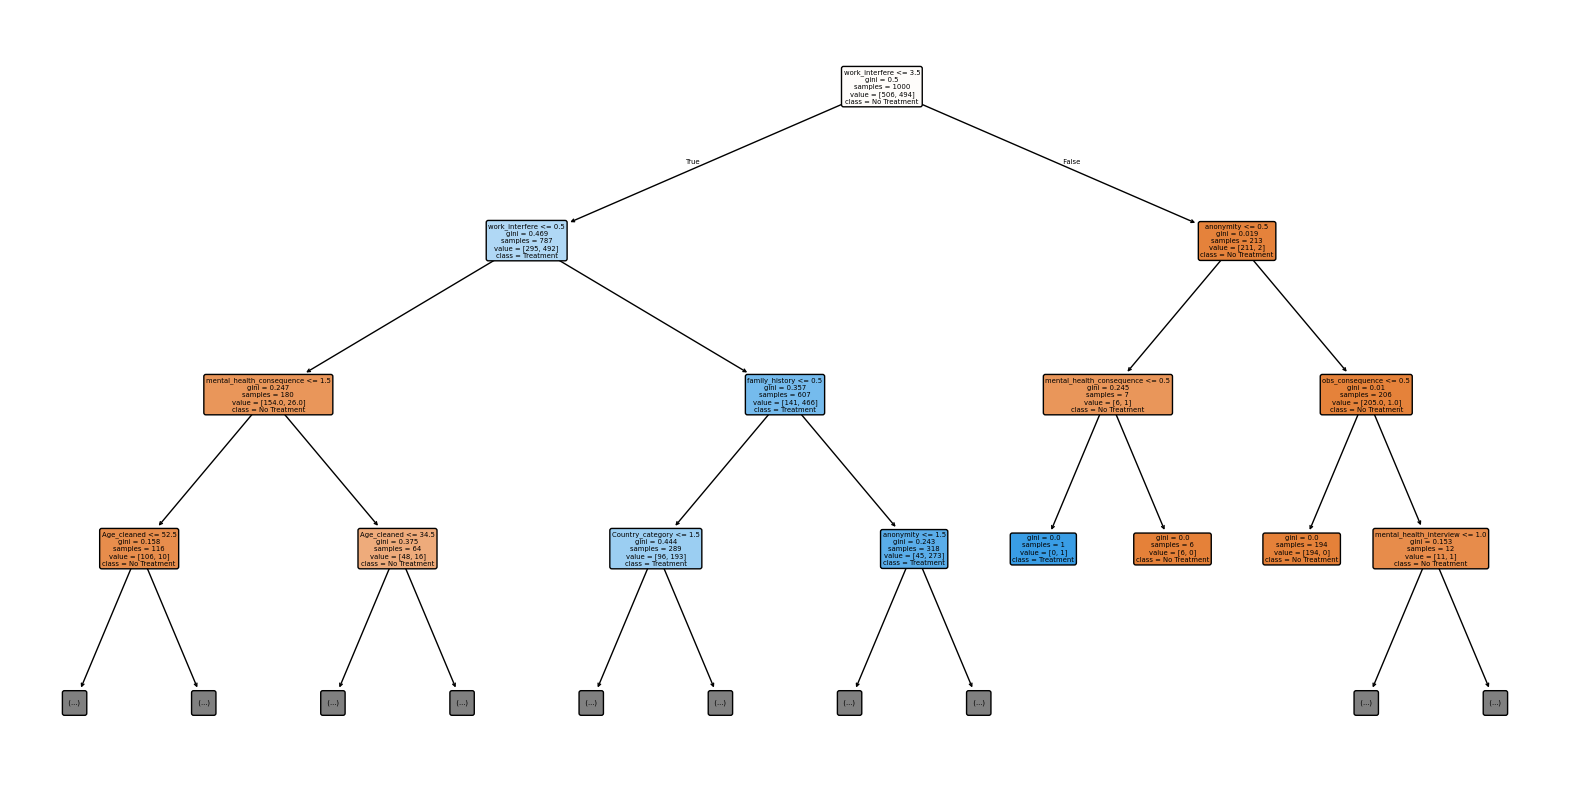

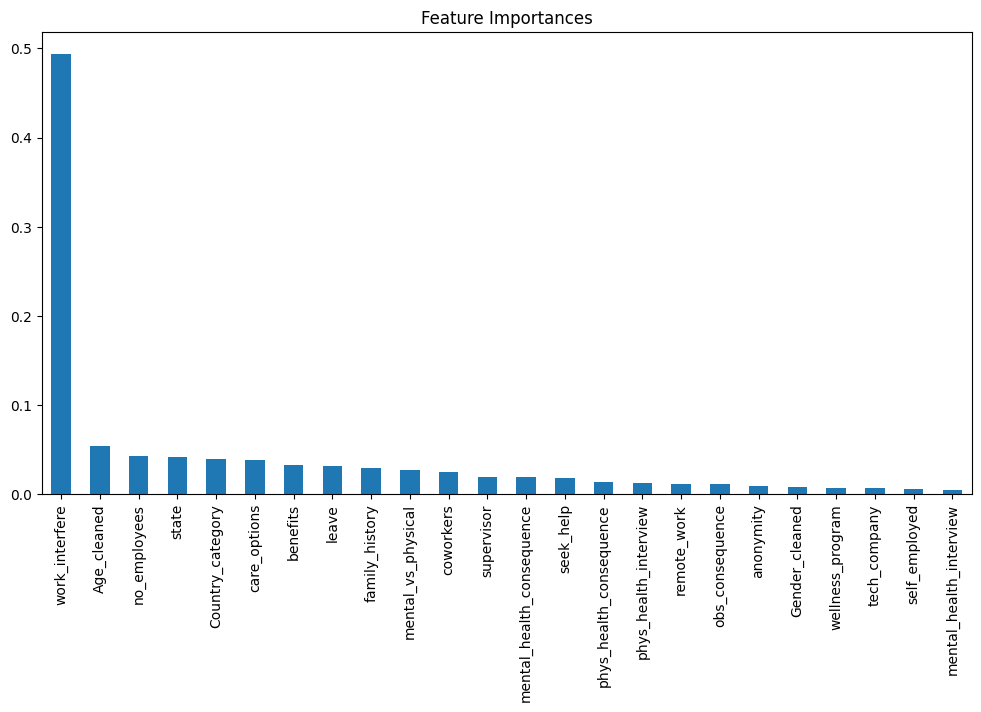


Feature:
work_interfere
Never                     14.15% (Treatment Rate)
Not applicable/Unknown     1.53% (Treatment Rate)
Often                      85.0% (Treatment Rate)
Rarely                    70.52% (Treatment Rate)
Sometimes                 76.94% (Treatment Rate)
Name: Yes, dtype: object


In [ ]:
#analyzing the resulting model
#visualization of the tree structure (80/20)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt_80_20, feature_names=features, class_names=['No Treatment', 'Treatment'], filled=True, rounded=True, max_depth=3)
plt.show()

#Feature importance (80/20)
feat_importances = pd.Series(dt_80_20.feature_importances_, index=features)
feat_importances = feat_importances.sort_values(ascending=False)

# plot feature importances
feat_importances.plot(kind='bar', figsize=(12,6), title='Feature Importances')
plt.show()

#top 1 most important features
top_1_features = feat_importances.head(1).index.tolist()


#Show distribution of treatment outcomes for each of the top features
for feature in top_1_features:
    print(f"\nFeature:")
    # Group by feature value and calculate percentage of treatment
    treatment_distribution = df.groupby(feature)['treatment'].value_counts(normalize=True).unstack().fillna(0)

    # Focus on % who received treatment (treatment = 1)
    treatment_percent = treatment_distribution['Yes'] * 100

    # Format output
    print(treatment_percent.round(2).astype(str) + '% (Treatment Rate)')

Accuracy (80/20 split): 0.7251


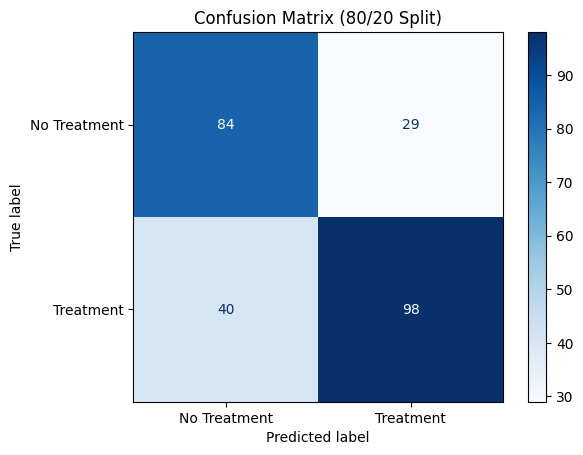

Classification Report (80/20 Split):
               precision    recall  f1-score   support

No Treatment       0.68      0.74      0.71       113
   Treatment       0.77      0.71      0.74       138

    accuracy                           0.73       251
   macro avg       0.72      0.73      0.72       251
weighted avg       0.73      0.73      0.73       251



In [ ]:
#evaluating the outcome - 80/20
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict

accuracy_80_20 = accuracy_score(Y_test, Y_pred_80_20)
print(f"Accuracy (80/20 split): {accuracy_80_20:.4f}")

cm = confusion_matrix(Y_test, Y_pred_80_20)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Treatment', 'Treatment'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (80/20 Split)')
plt.show()

# Generate classification report
report = classification_report(Y_test, Y_pred_80_20, target_names=['No Treatment', 'Treatment'])
print("Classification Report (80/20 Split):\n", report)

Cross-validation accuracy scores: [0.74603175 0.76       0.864      0.736      0.792      0.72
 0.728      0.744      0.728      0.736     ]
Mean accuracy (10-fold CV): 0.7554
Standard deviation: 0.0411


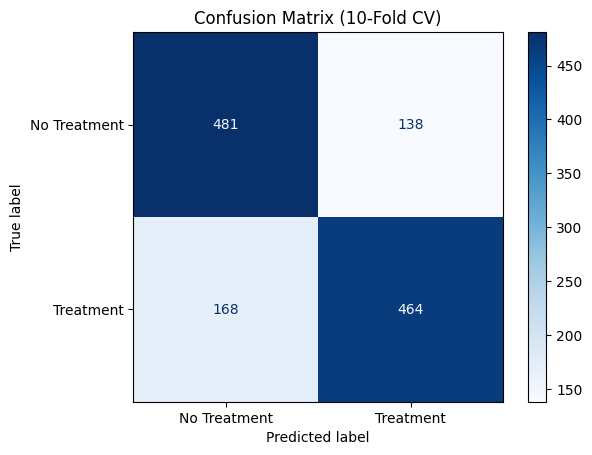

Classification Report (10-Fold CV):
              precision    recall  f1-score   support

No Treatment       0.74      0.78      0.76       619
   Treatment       0.77      0.73      0.75       632

    accuracy                           0.76      1251
   macro avg       0.76      0.76      0.76      1251
weighted avg       0.76      0.76      0.76      1251



In [ ]:
#evaluating the outcome - cross_validation
print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean accuracy (10-fold CV): {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")

# Get cross-validated predictions
Y_pred_cv = cross_val_predict(dt_cv, X, Y, cv=10)

# Confusion Matrix
cm_cv = confusion_matrix(Y, Y_pred_cv)
disp_cv = ConfusionMatrixDisplay(confusion_matrix=cm_cv, display_labels=['No Treatment', 'Treatment'])
disp_cv.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (10-Fold CV)')
plt.show()

# Classification Report
print("Classification Report (10-Fold CV):")
print(classification_report(Y, Y_pred_cv, target_names=['No Treatment', 'Treatment']))

####Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score

# Split into train/test sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Initialize Random Forest classifier
rf_80_20 = RandomForestClassifier(random_state=42)

# Train the model
rf_80_20.fit(X_train, Y_train)

# Predict on test set
Y_pred_rf_80_20 = rf_80_20.predict(X_test)

# Cross-validation method
rf_cv = RandomForestClassifier(random_state=42)
cv_scores_rf = cross_val_score(rf_cv, X, Y, cv=10, scoring='accuracy')

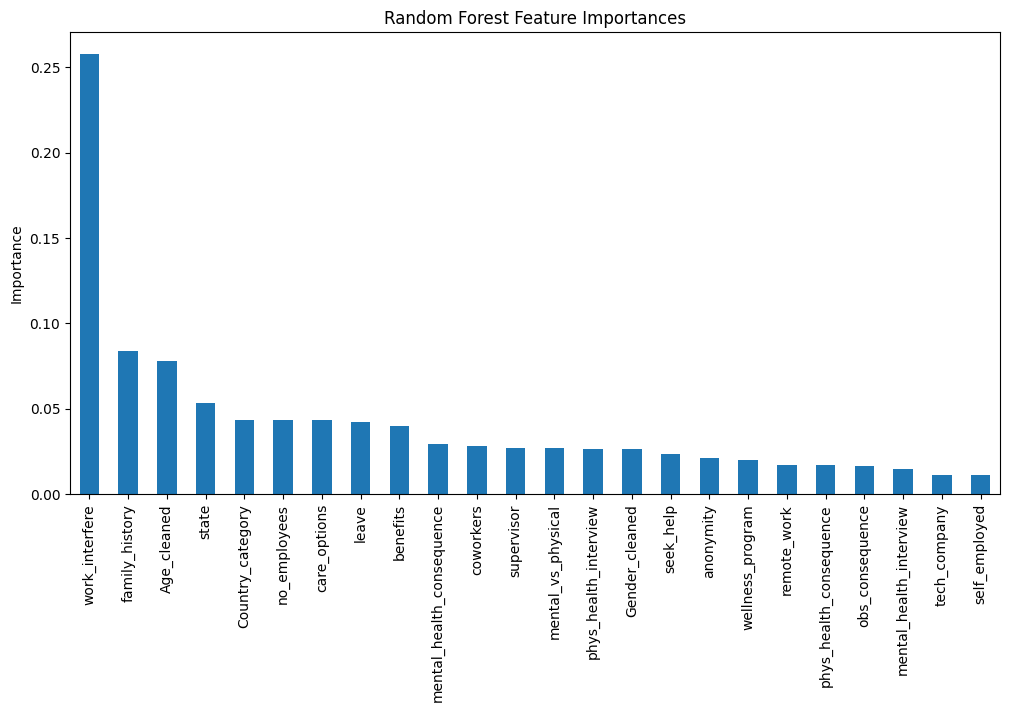


Feature:
work_interfere
Never                     14.15% (Treatment Rate)
Not applicable/Unknown     1.53% (Treatment Rate)
Often                      85.0% (Treatment Rate)
Rarely                    70.52% (Treatment Rate)
Sometimes                 76.94% (Treatment Rate)
Name: Yes, dtype: object

Feature:
family_history
No     35.43% (Treatment Rate)
Yes    74.03% (Treatment Rate)
Name: Yes, dtype: object


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance (80/20)
rf_feat_importances = pd.Series(rf_80_20.feature_importances_, index=features)
rf_feat_importances = rf_feat_importances.sort_values(ascending=False)

# Plot feature importances
rf_feat_importances.plot(kind='bar', figsize=(12,6), title='Random Forest Feature Importances')
plt.ylabel('Importance')
plt.show()

#top 2 most important features
top_2_features = rf_feat_importances.head(2).index.tolist()


#Show distribution of treatment outcomes for each of the top features
for feature in top_2_features:
    print(f"\nFeature:")
    # Group by feature value and calculate percentage of treatment
    treatment_distribution = df.groupby(feature)['treatment'].value_counts(normalize=True).unstack().fillna(0)

    # Focus on % who received treatment (treatment = 1)
    treatment_percent = treatment_distribution['Yes'] * 100

    # Format output
    print(treatment_percent.round(2).astype(str) + '% (Treatment Rate)')

Random Forest Accuracy (80/20 split): 0.8008


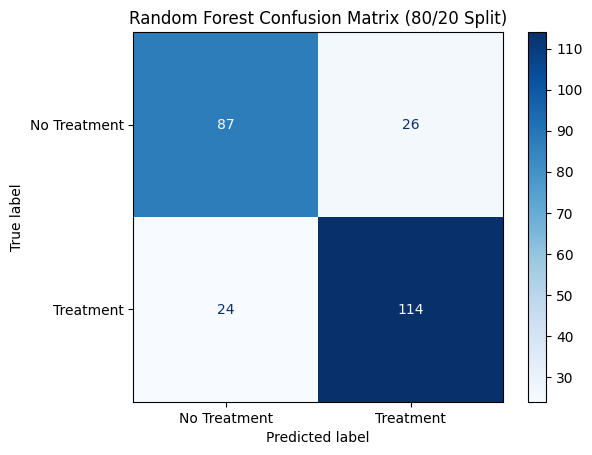

Random Forest Classification Report (80/20 Split):
               precision    recall  f1-score   support

No Treatment       0.78      0.77      0.78       113
   Treatment       0.81      0.83      0.82       138

    accuracy                           0.80       251
   macro avg       0.80      0.80      0.80       251
weighted avg       0.80      0.80      0.80       251



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Accuracy
accuracy_rf_80_20 = accuracy_score(Y_test, Y_pred_rf_80_20)
print(f"Random Forest Accuracy (80/20 split): {accuracy_rf_80_20:.4f}")

# Confusion matrix
cm_rf = confusion_matrix(Y_test, Y_pred_rf_80_20)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Treatment', 'Treatment'])
disp_rf.plot(cmap=plt.cm.Blues)
plt.title('Random Forest Confusion Matrix (80/20 Split)')
plt.show()

# Classification report
report_rf = classification_report(Y_test, Y_pred_rf_80_20, target_names=['No Treatment', 'Treatment'])
print("Random Forest Classification Report (80/20 Split):\n", report_rf)

Random Forest CV Accuracy Scores: [0.79365079 0.832      0.864      0.832      0.832      0.816
 0.824      0.816      0.776      0.792     ]
Mean Accuracy (10-Fold CV): 0.8178
Standard Deviation: 0.0240


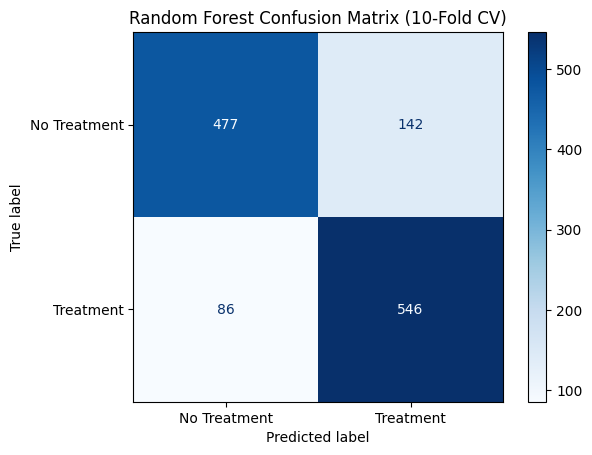

Random Forest Classification Report (10-Fold CV):
              precision    recall  f1-score   support

No Treatment       0.85      0.77      0.81       619
   Treatment       0.79      0.86      0.83       632

    accuracy                           0.82      1251
   macro avg       0.82      0.82      0.82      1251
weighted avg       0.82      0.82      0.82      1251



In [ ]:
from sklearn.model_selection import cross_val_predict

# Cross-validation accuracy
print(f"Random Forest CV Accuracy Scores: {cv_scores_rf}")
print(f"Mean Accuracy (10-Fold CV): {cv_scores_rf.mean():.4f}")
print(f"Standard Deviation: {cv_scores_rf.std():.4f}")

# Get cross-validated predictions
Y_pred_rf_cv = cross_val_predict(rf_cv, X, Y, cv=10)

# Confusion matrix
cm_rf_cv = confusion_matrix(Y, Y_pred_rf_cv)
disp_rf_cv = ConfusionMatrixDisplay(confusion_matrix=cm_rf_cv, display_labels=['No Treatment', 'Treatment'])
disp_rf_cv.plot(cmap=plt.cm.Blues)
plt.title('Random Forest Confusion Matrix (10-Fold CV)')
plt.show()

# Classification report
print("Random Forest Classification Report (10-Fold CV):")
print(classification_report(Y, Y_pred_rf_cv, target_names=['No Treatment', 'Treatment']))

### Model for Counry-level DIfferences in Openness about Mental Health in workplace
#### Decision Tree

In [ ]:
# Selection of attributes of interest with defining target attribute and features
openness_features = ['benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave',
               'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview',
               'phys_health_interview', 'mental_vs_physical', 'obs_consequence']
openness_target = ['United States', 'United Kingdom', 'Canada', 'Germany', 'Ireland', 'Netherlands', 'Australia', 'France',
               'India', 'New Zealand', 'Other']
# Encoding data from categorical (string) to numerical (integers)
openness_model_data = df[openness_features + ['Country_category']].copy()
openness_model_data['Country_category'] = openness_model_data['Country_category'].map(country_map)
openness_model_data['leave'] = openness_model_data['leave'].map(leave_map)

openness_model_data['benefits'] = openness_model_data['benefits'].map(yes_no_dk_map)
openness_model_data['wellness_program'] = openness_model_data['wellness_program'].map(yes_no_dk_map)
openness_model_data['seek_help'] = openness_model_data['seek_help'].map(yes_no_dk_map)
openness_model_data['anonymity'] = openness_model_data['anonymity'].map(yes_no_dk_map)
openness_model_data['mental_vs_physical'] = openness_model_data['mental_vs_physical'].map(yes_no_dk_map)

openness_model_data['mental_health_consequence'] = openness_model_data['mental_health_consequence'].map(yes_no_maybe_map)
openness_model_data['phys_health_consequence'] = openness_model_data['phys_health_consequence'].map(yes_no_maybe_map)
openness_model_data['mental_health_interview'] = openness_model_data['mental_health_interview'].map(yes_no_maybe_map)
openness_model_data['phys_health_interview'] = openness_model_data['phys_health_interview'].map(yes_no_maybe_map)

openness_model_data['care_options'] = openness_model_data['care_options'].map(yes_no_notsure_map)

openness_model_data['coworkers'] = openness_model_data['coworkers'].map(yes_no_some_map)
openness_model_data['supervisor'] = openness_model_data['supervisor'].map(yes_no_some_map)

openness_model_data['obs_consequence'] = openness_model_data['obs_consequence'].apply(lambda x: 1 if x == 'Yes' else 0)

# evaluation of model function
def model_eval(x, y, model, target):
    # Create confusion matrix
    cm_openness = confusion_matrix(x, y)

    disp_op = ConfusionMatrixDisplay(confusion_matrix=cm_openness, display_labels=target)
    disp_op.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.xticks(rotation=60)
    plt.show()

    # Generate classification report
    report_openness = classification_report(x, y, target_names=target)
    print("Classification Report:\n", report_openness)

    #Feature importance
    feat_importances_op = pd.Series(model.feature_importances_, index=openness_features)
    feat_importances_op = feat_importances_op.sort_values(ascending=False)

    # plot feature importances
    feat_importances_op.plot(kind='bar', figsize=(12,6), title='Feature Importances')
    plt.show()

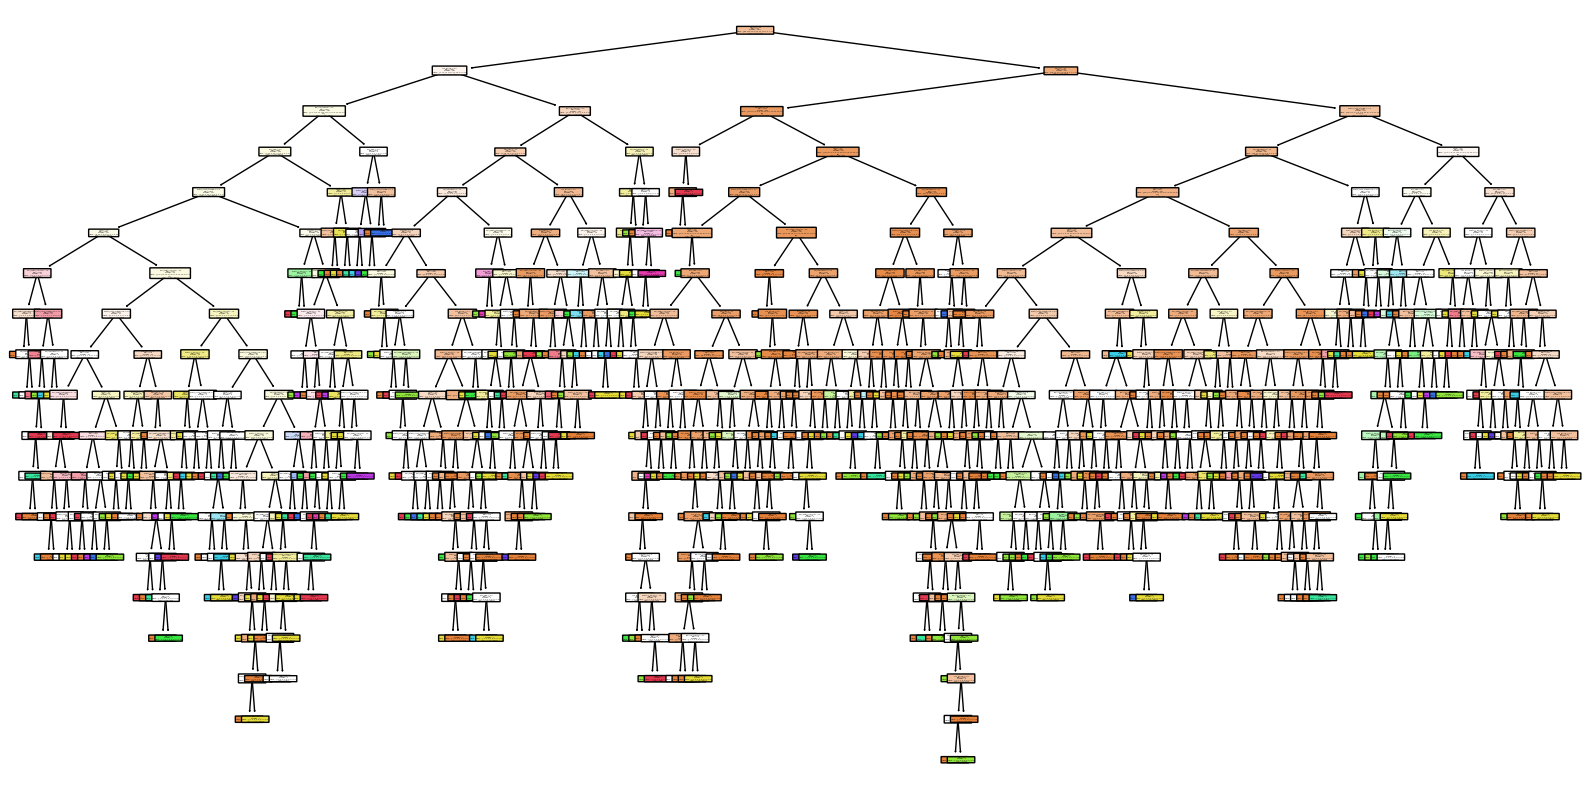

In [ ]:
# splitting data into training 80% and testing data 20%
# of - openness_features   ot - openness target
of_train, of_test, ot_train, ot_test = train_test_split(openness_model_data[openness_features], openness_model_data['Country_category'], test_size=0.2, random_state=42)
# Developing Decision Tree based on training data
tree_opennes = DecisionTreeClassifier(random_state=42)
tree_opennes.fit(of_train, ot_train)

# Predicting values for testing data
tree_openness_predict = tree_opennes.predict(of_test)

plt.figure(figsize=(20,10))
plot_tree(tree_opennes, feature_names=openness_features, class_names=openness_target, filled=True, rounded=True)
plt.show()

Accuracy (80/20 split): 0.4861


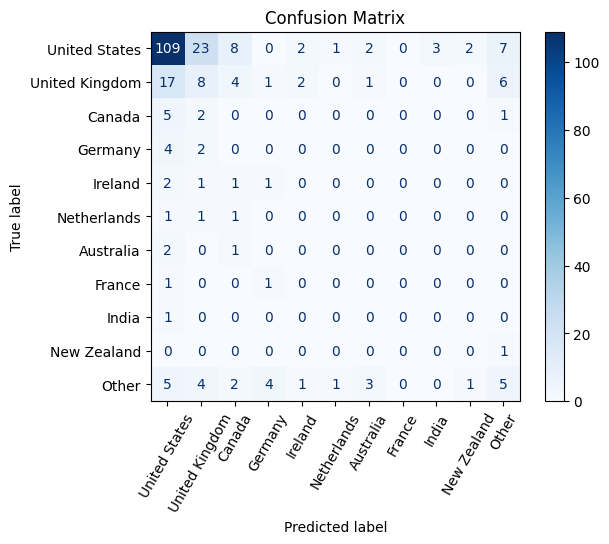

Classification Report:
                 precision    recall  f1-score   support

 United States       0.74      0.69      0.72       157
United Kingdom       0.20      0.21      0.20        39
        Canada       0.00      0.00      0.00         8
       Germany       0.00      0.00      0.00         6
       Ireland       0.00      0.00      0.00         5
   Netherlands       0.00      0.00      0.00         3
     Australia       0.00      0.00      0.00         3
        France       0.00      0.00      0.00         2
         India       0.00      0.00      0.00         1
   New Zealand       0.00      0.00      0.00         1
         Other       0.25      0.19      0.22        26

      accuracy                           0.49       251
     macro avg       0.11      0.10      0.10       251
  weighted avg       0.52      0.49      0.50       251



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


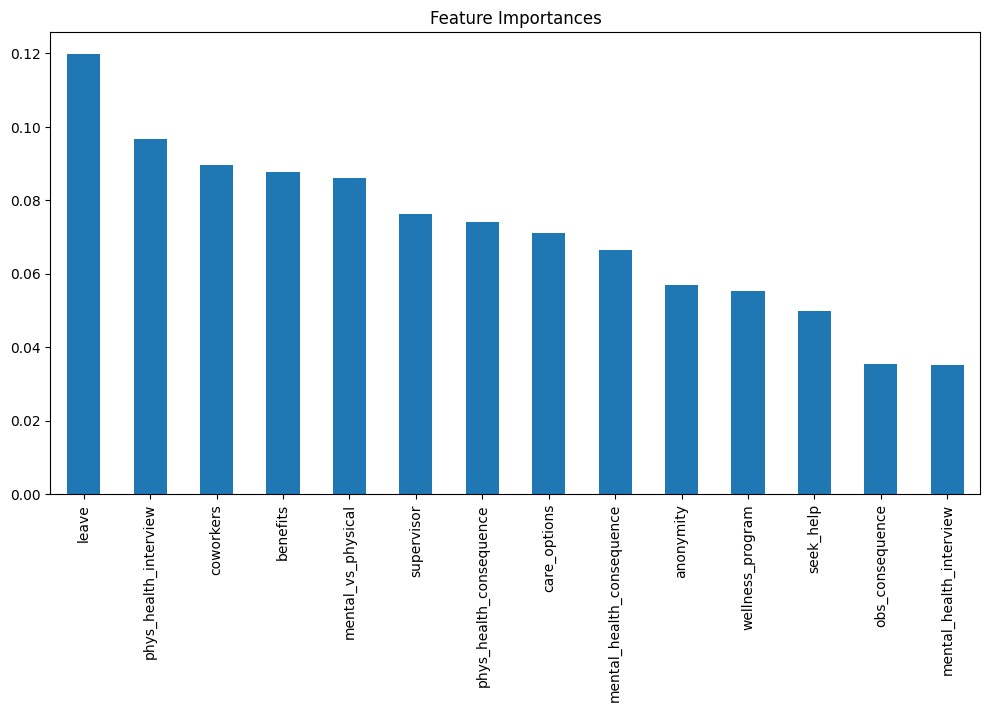

In [ ]:
# Checking accuracy of the model

accuracy = accuracy_score(ot_test, tree_openness_predict)
print(f"Accuracy (80/20 split): {accuracy:.4f}")
model_eval(ot_test, tree_openness_predict, tree_opennes, openness_target)

Features that are the most significant (over 0.8 treshold) when splitting the tree are: possibility to take medical leave for mental health condition (leave), probability of bringing up physical health during interview with potential employer (phys_health_interview), wheather respondent talks about mental health with their coworkers (coworkers), mental health benefits offered by employer (benefits) and feeling that employer is taking mental health as seriousily as physical health (mental_vs_phys).

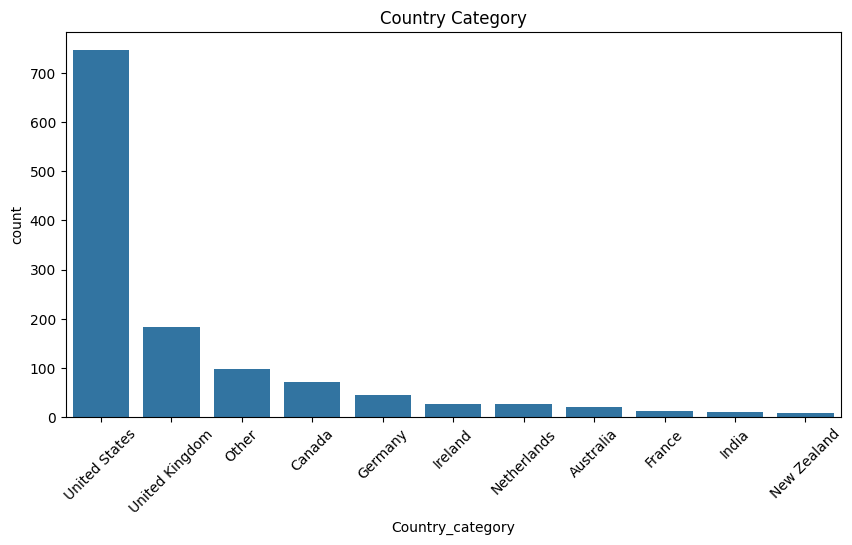

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,5))
counts = df['Country_category'].value_counts()
sns.countplot(data=df, x=df['Country_category'], order=counts.index)
plt.title('Country Category')
plt.xticks(rotation=45)
plt.show()

The accuracy of this model is around 0.5. Model predicts best for USA and for some countries model is not able to predict any value. This is due to the fact that most respondents are from USA, therefore the results are skewed. The disability of prediction for some countries may be due to the fact that in training data ths country did not appear.  
Model needs to be improved further. Cross-validation method for splitting data will be used to improve model prediction for other countries tha USA by giving them more probability to be included in training set.
##### Cross-validation Method for Decision Tree

Cross-validation accuracy scores: [0.47770701 0.4522293  0.50955414 0.44871795 0.43589744 0.43589744
 0.44230769 0.44230769]
Mean accuracy: 0.4556
Standard deviation: 0.0239


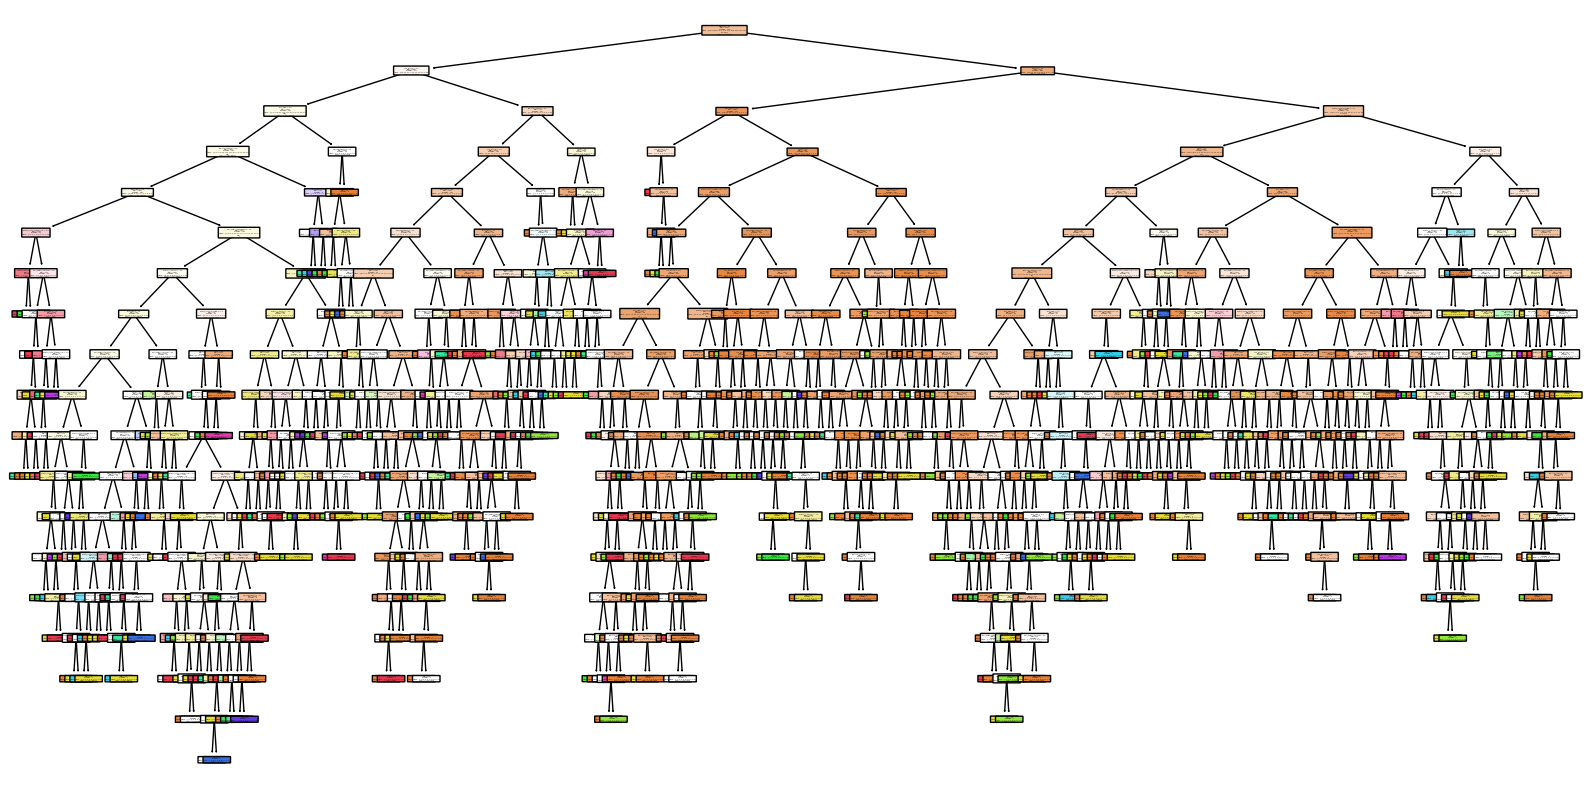

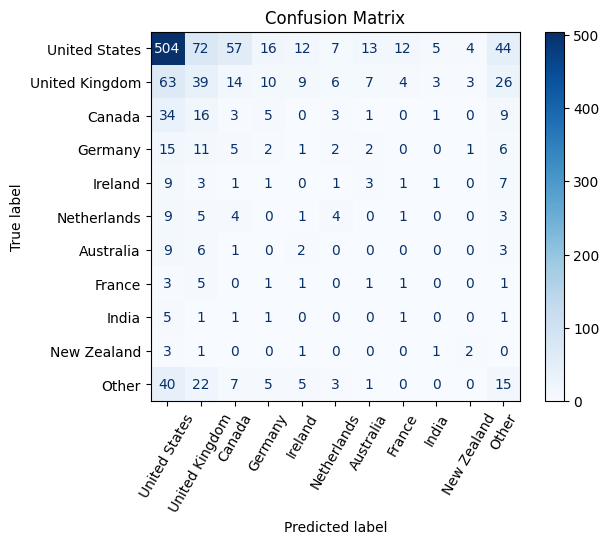

Classification Report:
                 precision    recall  f1-score   support

 United States       0.73      0.68      0.70       746
United Kingdom       0.22      0.21      0.21       184
        Canada       0.03      0.04      0.04        72
       Germany       0.05      0.04      0.05        45
       Ireland       0.00      0.00      0.00        27
   Netherlands       0.15      0.15      0.15        27
     Australia       0.00      0.00      0.00        21
        France       0.05      0.08      0.06        13
         India       0.00      0.00      0.00        10
   New Zealand       0.20      0.25      0.22         8
         Other       0.13      0.15      0.14        98

      accuracy                           0.46      1251
     macro avg       0.14      0.15      0.14      1251
  weighted avg       0.48      0.46      0.47      1251



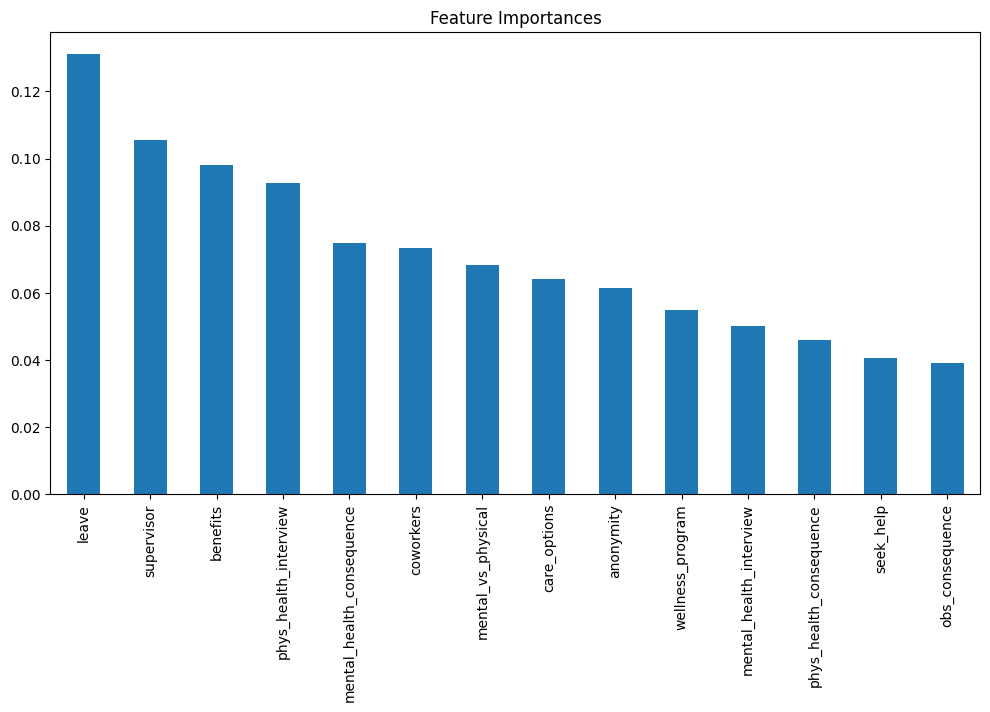

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_predict
# Developing Decision Tree predictor model
tree_opennes_cv = DecisionTreeClassifier(random_state=42)

# Using Stratified k fold for cross validation with 8 fold since the least populated class has 8 members
skf_openness = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)

# Calculating cross validation scores
cv_scores_openness = cross_val_score(tree_opennes_cv, openness_model_data[openness_features], openness_model_data['Country_category'], cv=skf_openness, scoring='accuracy')

# Predicting values for cross validation
tree_openness_cv_predict = cross_val_predict(tree_opennes_cv, openness_model_data[openness_features], openness_model_data['Country_category'], cv=skf_openness)

#evaluating the outcome - cross_validation
print(f"Cross-validation accuracy scores: {cv_scores_openness}")
print(f"Mean accuracy: {cv_scores_openness.mean():.4f}")
print(f"Standard deviation: {cv_scores_openness.std():.4f}")

# Present tree and feature importances
tree_opennes_cv.fit(openness_model_data[openness_features], openness_model_data['Country_category'])
plt.figure(figsize=(20,10))
plot_tree(tree_opennes_cv, feature_names=openness_features, class_names=openness_target, filled=True, rounded=True)
plt.show()

model_eval(openness_model_data['Country_category'], tree_openness_cv_predict, tree_opennes_cv, openness_target)

Accuracy of model with the corss-validation using stratified k fold with 8 folds did not improve accuracy. Mean accuracy is lower for cross validation than previousily. At the same time precision of model prediction improved for some countries - UK, Canada, Germany, Netherlands, France and New Zealand. Some countries still cannot be predicted by model due to inbalance of number of members in country category class.  
Features that are the most significant (over 0.8 treshold) when splitting the tree are: possibility to take medical leave for mental health condition (leave), wheather respondent talks about mental health with their supervisor (supervisor), mental health benefits offered by employer (benefits), probability of bringing up physical health during interview with potential employer (phys_health_interview).  
In order to improve accuracy of the model Random Forest method will be applied for both 80/20 split and cross validation with stratification.
#### Random Forest

Accuracy (80/20 split): 0.5737


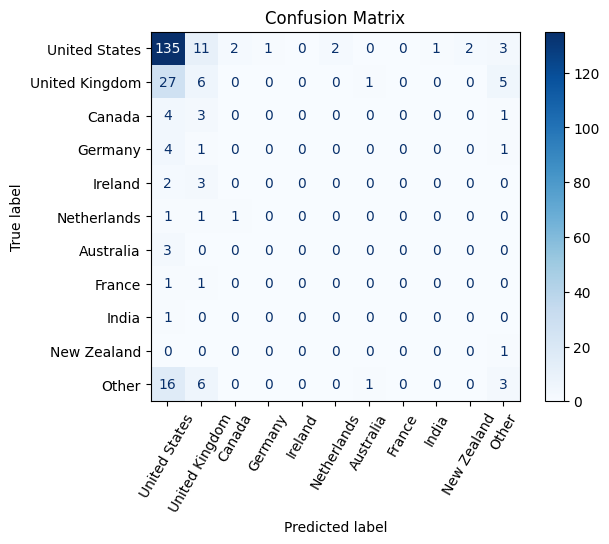

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
                 precision    recall  f1-score   support

 United States       0.70      0.86      0.77       157
United Kingdom       0.19      0.15      0.17        39
        Canada       0.00      0.00      0.00         8
       Germany       0.00      0.00      0.00         6
       Ireland       0.00      0.00      0.00         5
   Netherlands       0.00      0.00      0.00         3
     Australia       0.00      0.00      0.00         3
        France       0.00      0.00      0.00         2
         India       0.00      0.00      0.00         1
   New Zealand       0.00      0.00      0.00         1
         Other       0.21      0.12      0.15        26

      accuracy                           0.57       251
     macro avg       0.10      0.10      0.10       251
  weighted avg       0.49      0.57      0.52       251



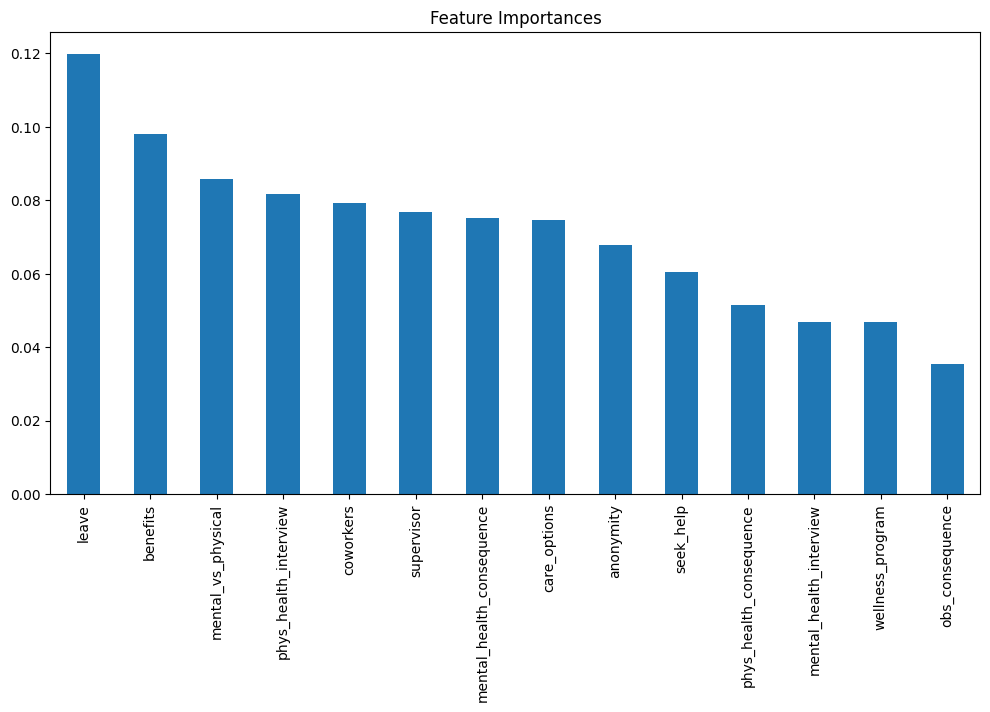

In [ ]:
# splitting data into training 80% and testing data 20%
# of - openness_features   ot - openness target
of_train, of_test, ot_train, ot_test = train_test_split(openness_model_data[openness_features], openness_model_data['Country_category'], test_size=0.2, random_state=42)

# Developing Decision Tree based on training data
rf_opennes = RandomForestClassifier(random_state=42)
rf_opennes_train = rf_opennes.fit(of_train, ot_train)

# Predicting values for testing data
rf_openness_predict = rf_opennes.predict(of_test)

# Checking accuracy of the model
accuracy_80_20_rf_openness = accuracy_score(ot_test, rf_openness_predict)
print(f"Accuracy (80/20 split): {accuracy_80_20_rf_openness:.4f}")

model_eval(ot_test, rf_openness_predict, rf_opennes, openness_target)

Features that are the most significant (over 0.8 treshold) are: possibility to take medical leave for mental health condition (leave), mental health benefits offered by employer (benefits), and feeling that emplyer is taking mental health as seriousily as physical health (mental_vs_phys), probability of bringing up physical health during interview with potential employer (phys_health_interview).  
Overall accuracy of the model increased to 0.57 but still some of the countries are not predicted at all by the model. Again the reason could be significant advantage of USA respondents.  
Now Random Forest model for cross validation will be developed to improve overall accuracy and increase precision of prediction for more countries.
##### Cross-validation method for Random Forest

Cross-validation accuracy scores: [0.59235669 0.58598726 0.59872611 0.55769231 0.55769231 0.53846154
 0.57692308 0.6025641 ]
Mean accuracy: 0.5763
Standard deviation: 0.0214


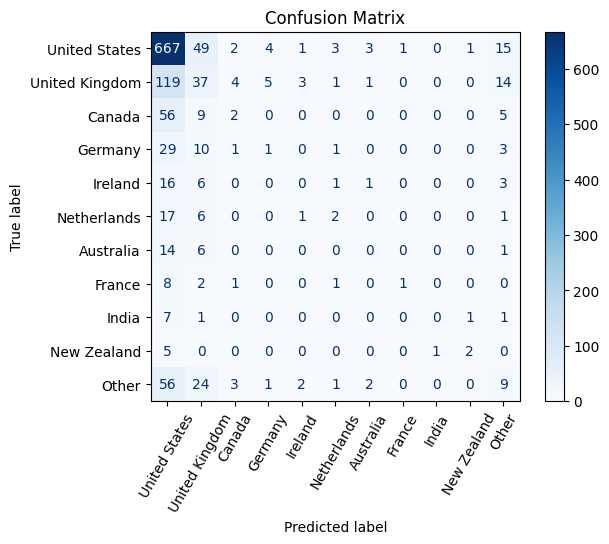

Classification Report:
                 precision    recall  f1-score   support

 United States       0.67      0.89      0.77       746
United Kingdom       0.25      0.20      0.22       184
        Canada       0.15      0.03      0.05        72
       Germany       0.09      0.02      0.04        45
       Ireland       0.00      0.00      0.00        27
   Netherlands       0.20      0.07      0.11        27
     Australia       0.00      0.00      0.00        21
        France       0.50      0.08      0.13        13
         India       0.00      0.00      0.00        10
   New Zealand       0.50      0.25      0.33         8
         Other       0.17      0.09      0.12        98

      accuracy                           0.58      1251
     macro avg       0.23      0.15      0.16      1251
  weighted avg       0.47      0.58      0.51      1251



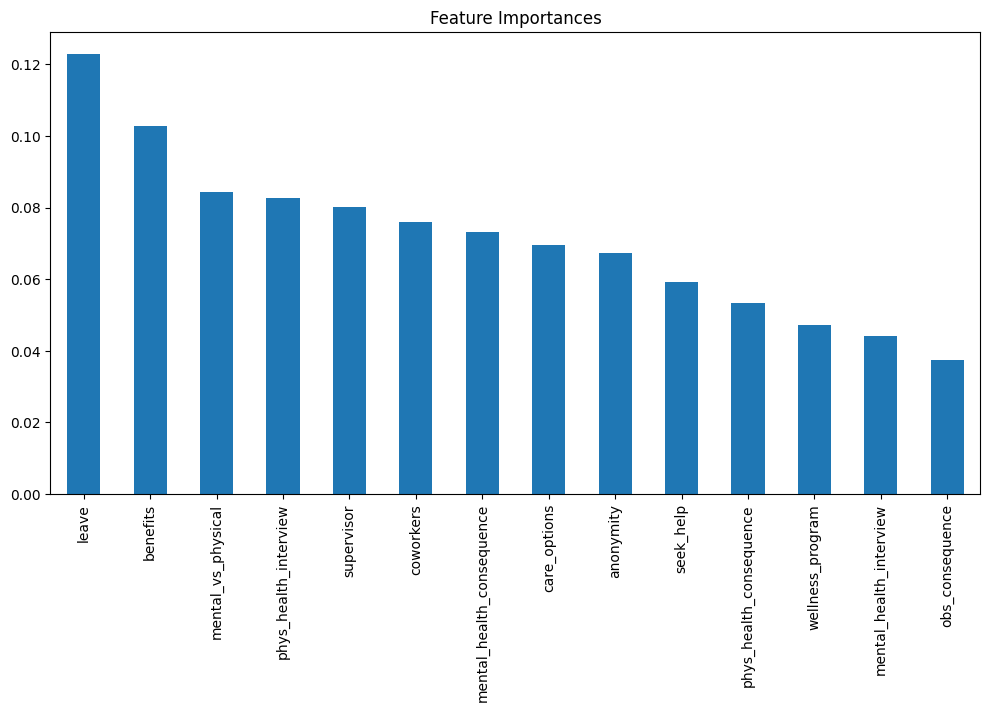

In [ ]:
# Developing Decision Tree predictor model
rf_opennes_cv = RandomForestClassifier(random_state=42)

# Calculating cross validation scores wth stratified k fold method with 8 folds (developed for Decision Tree with cross-validation)
cv_scores_openness_rf = cross_val_score(rf_opennes_cv, openness_model_data[openness_features], openness_model_data['Country_category'], cv=skf_openness, scoring='accuracy')

# Predicting values for cross validation
rf_openness_cv_predict = cross_val_predict(rf_opennes_cv, openness_model_data[openness_features], openness_model_data['Country_category'], cv=skf_openness)

#evaluating the outcome - cross_validation
print(f"Cross-validation accuracy scores: {cv_scores_openness_rf}")
print(f"Mean accuracy: {cv_scores_openness_rf.mean():.4f}")
print(f"Standard deviation: {cv_scores_openness_rf.std():.4f}")


rf_opennes_cv.fit(openness_model_data[openness_features], openness_model_data['Country_category'])

model_eval(openness_model_data['Country_category'], rf_openness_cv_predict, rf_opennes_cv, openness_target)

Accuracy of Random Forest with cross-validation didn't increase significantly compared to Random Forest with 80-20 split. However Precision for some countries increased significantly giving 0.5 precision for France and New Zealand, 0.25 for UK, 0.2 for Netherlands, 0.15 for Canada and 0.67 for USA.  
This is the best model untill now for country level differences in openness about mental health.  
Low results for accuracy and precision are most likely due to skewed distribution of country attribute in the dataset. Furter improvement of accuracy could be achieved by merging some countries for example european countries in order to balance the distribution. Model for this scenario will be developed in the next section - Experiments with Model and Dataset as well as clustering with k-means algorythm.  
Features that are the most significant (over 0.8 treshold) are: possibility to take medical leave for mental health condition (leave), mental health benefits offered by employer (benefits), and feeling that emplyer is taking mental health as seriousily as physical health (mental_vs_phys), probability of bringing up physical health during interview with potential employer (phys_health_interview).  

### **Experiments with Model and Dataset**

#### Improvement of Accuracy of Random Forest with cross-validation for Country attribute
Further improvement of the model in order to achieve highier accuracy and better precision for classes of country attribute will include meging of country classes to balance distribution of the attribute. From the set of all countries that appeared in original dataset new classes will be made such as: USA (as it is now), eu_countries (european countries), asian_african_countries (countries from Asia and Africa), au_ne_am_countries (Australia, New Zealand and countries from America beside USA)

Country_class
United States         746
EU_countries          358
Au_NZ_Am_countries    113
Asian_countries        26
African_countries       8
Name: count, dtype: int64


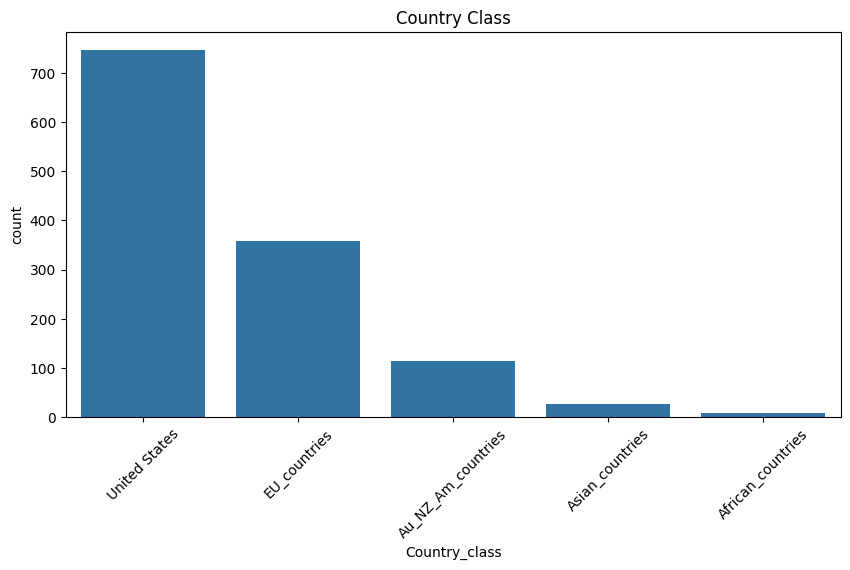

In [ ]:
# Grouping countries to more balanced groups
european_countries = ['United Kingdom', 'Germany', 'Netherlands', 'Ireland', 'France', 'Italy', 'Switzerland', 'Poland', 'Sweden', 'Belgium', 'Bulgaria',
                      'Finland', 'Austria', 'Portugal', 'Denmark', 'Croatia', 'Greece', 'Spain', 'Latvia', 'Romania', 'Slovenia', 'Hungary', 'Bosnia and Herzegovina',
                      'Norway', 'Moldova', 'Georgia', 'Czech Republic']
# Australia, New Zealand and Countries in America beside USA
au_nz_am_countries = ['Australia', 'New Zealand', 'Brazil',  'Mexico', 'Colombia', 'Costa Rica', 'Canada']
asian_countries = ['India', 'Israel', 'Singapore', 'Russia', 'Japan', 'Thailand', 'China', 'Philippines']
african_countries = ['South Africa', 'Uruguay', 'Nigeria']

df['Country_class'] = df['Country'].apply(lambda x: 'EU_countries' if x in european_countries else
                                          ('Au_NZ_Am_countries' if x in au_nz_am_countries else
                                          ('Asian_countries' if x in asian_countries else
                                          ('African_countries' if x in african_countries else x))))

print(df['Country_class'].value_counts())

#Draw plot of new category Country_class
plt.figure(figsize=(10,5))
counts = df['Country_class'].value_counts()
sns.countplot(data=df, x=df['Country_class'], order=counts.index)
plt.title('Country Class')
plt.xticks(rotation=45)
plt.show()

# Mapping of new variable to model dataframe
openness_model_data['Country_class'] = df['Country_class']
countries_class_map = {'United States': 0,
                       'EU_countries': 1,
                       'Au_NZ_Am_countries': 2,
                       'Asian_countries': 3,
                       'African_countries': 4}

openness_model_data['Country_class'] = openness_model_data['Country_class'].map(countries_class_map)

Since the best model developed in Model Creation section for finding differences between countries for openness to mental health was Random Forest with cross-validation, this model will be now used with new attribute Country_class

Cross-validation accuracy scores: [0.67515924 0.63694268 0.6433121  0.67948718 0.58333333 0.58974359
 0.59615385 0.69230769]
Mean accuracy: 0.6371
Standard deviation: 0.0405


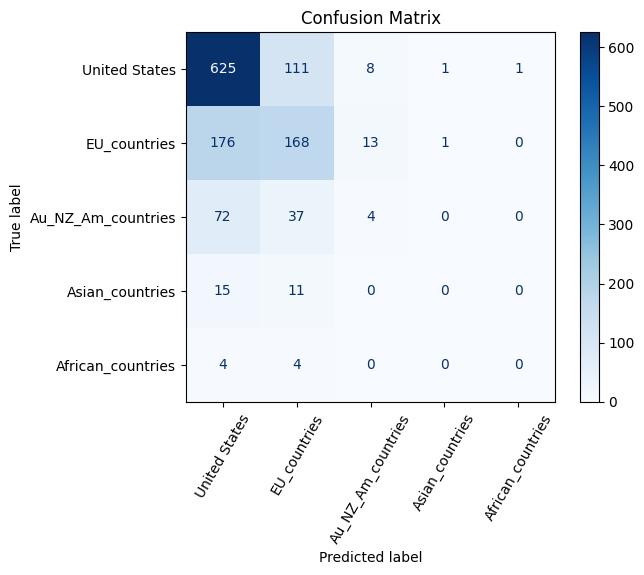

Classification Report:
                     precision    recall  f1-score   support

     United States       0.70      0.84      0.76       746
      EU_countries       0.51      0.47      0.49       358
Au_NZ_Am_countries       0.16      0.04      0.06       113
   Asian_countries       0.00      0.00      0.00        26
 African_countries       0.00      0.00      0.00         8

          accuracy                           0.64      1251
         macro avg       0.27      0.27      0.26      1251
      weighted avg       0.58      0.64      0.60      1251



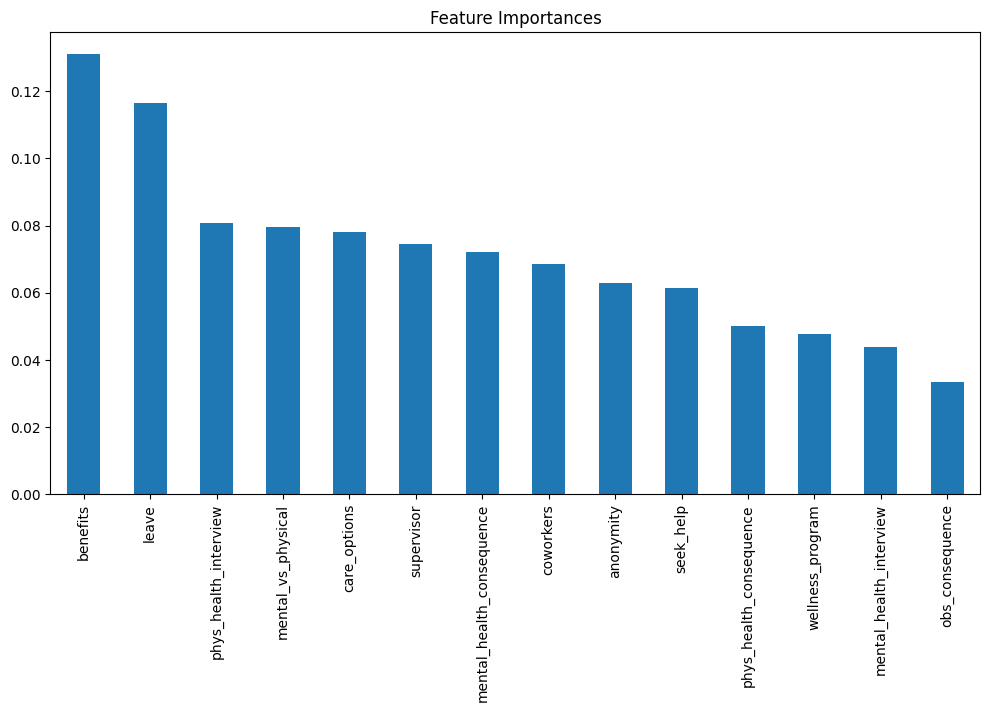

In [ ]:
new_openness_target = ['United States', 'EU_countries', 'Au_NZ_Am_countries', 'Asian_countries', 'African_countries']

# Developing Decision Tree predictor model
new_rf_opennes_cv = RandomForestClassifier(random_state=42)

# Using Stratified k fold for cross validation with 8 fold ( this is the lowest number of members in one class)
new_skf_openness = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)

# Calculating cross validation scores wth stratified k fold method with 8 folds (developed for Decision Tree with cross-validation)
new_cv_scores_openness_rf = cross_val_score(new_rf_opennes_cv, openness_model_data[openness_features], openness_model_data['Country_class'],
                                            cv=new_skf_openness, scoring='accuracy')

# Predicting values for cross validation
new_rf_openness_cv_predict = cross_val_predict(new_rf_opennes_cv, openness_model_data[openness_features], openness_model_data['Country_class'], cv=new_skf_openness)

#evaluating the outcome - cross_validation
print(f"Cross-validation accuracy scores: {new_cv_scores_openness_rf}")
print(f"Mean accuracy: {new_cv_scores_openness_rf.mean():.4f}")
print(f"Standard deviation: {new_cv_scores_openness_rf.std():.4f}")

new_rf_opennes_cv.fit(openness_model_data[openness_features], openness_model_data['Country_class'])

model_eval(openness_model_data['Country_class'], new_rf_openness_cv_predict, new_rf_opennes_cv, new_openness_target)

An improvement of accuracy can be observed now with avarage accuracy being 0.64. Precision for eurpoean countries has a moderate result of 0.51 and group with Australia, New   Zealand and America is 0.16. Asian and African countries group is not predicted by model probably due to small sample of those countries in the data or too big differences between those countries which could lead to hiding some patterns.  
This model is better than the ones developed previousily for topic of countries openness but there is one issue of possible hiding of some important patterns due to mannual grouping of Country attribute members.  
Features that are the most significant (over 0.8 treshold) are: mental health benefits offered by employer (benefits) and possibility to take medical leave for mental health condition (leave).
##### Clustering Algorythm k-means
Clustering algorithm will be performed for Random Forest with clustering in order to increase accuracy of the model and precision per cluster.

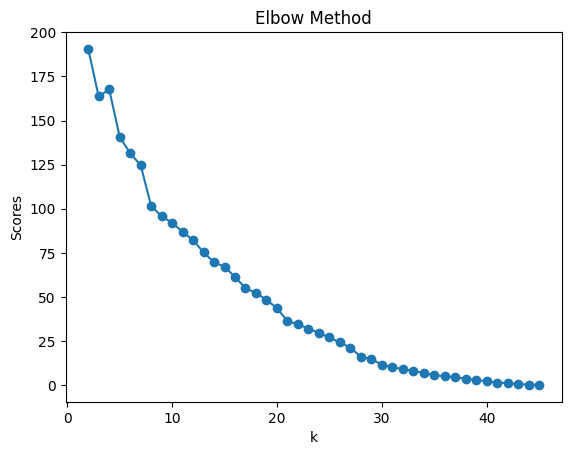

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prepare data for clustering - grouping responses by country and calculating mean for the features per each country
openness_model_data['Country_name'] = df['Country']
country_cluster_data = openness_model_data.groupby('Country_name')[openness_features].mean().reset_index()

# Check for best k - number of clusters (46 is number of countries in dataframe)
scores = []
for k in range(2, 46):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
    kmeans.fit(country_cluster_data[openness_features])
    # scores retun within cluster sum of squares
    scores.append(-kmeans.score(country_cluster_data[openness_features]))

# View results of fitting into graph
plt.plot(range(2, 46), scores, marker='o')
plt.xlabel('k')
plt.ylabel('Scores')
plt.title('Elbow Method')
plt.show()

To decide which k is the best we look for a point after which the slope is not so steep. In this case it would be k=7 or k = 20. For both k Random Forest with cross validation (10-fold) will be developed and their accuracy checked.

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Cross-validation accuracy scores: [0.92857143 0.92       0.912      0.912      0.896      0.92
 0.912      0.912      0.912      0.904     ]
Mean accuracy: 0.9129
Standard deviation: 0.0085


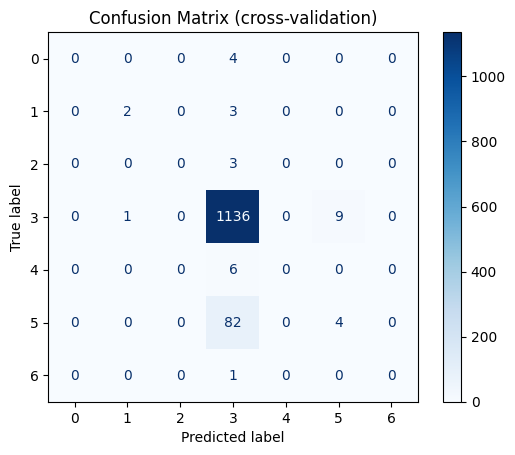

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report (cross-validation):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.67      0.40      0.50         5
           2       0.00      0.00      0.00         3
           3       0.92      0.99      0.95      1146
           4       0.00      0.00      0.00         6
           5       0.31      0.05      0.08        86
           6       0.00      0.00      0.00         1

    accuracy                           0.91      1251
   macro avg       0.27      0.21      0.22      1251
weighted avg       0.87      0.91      0.88      1251



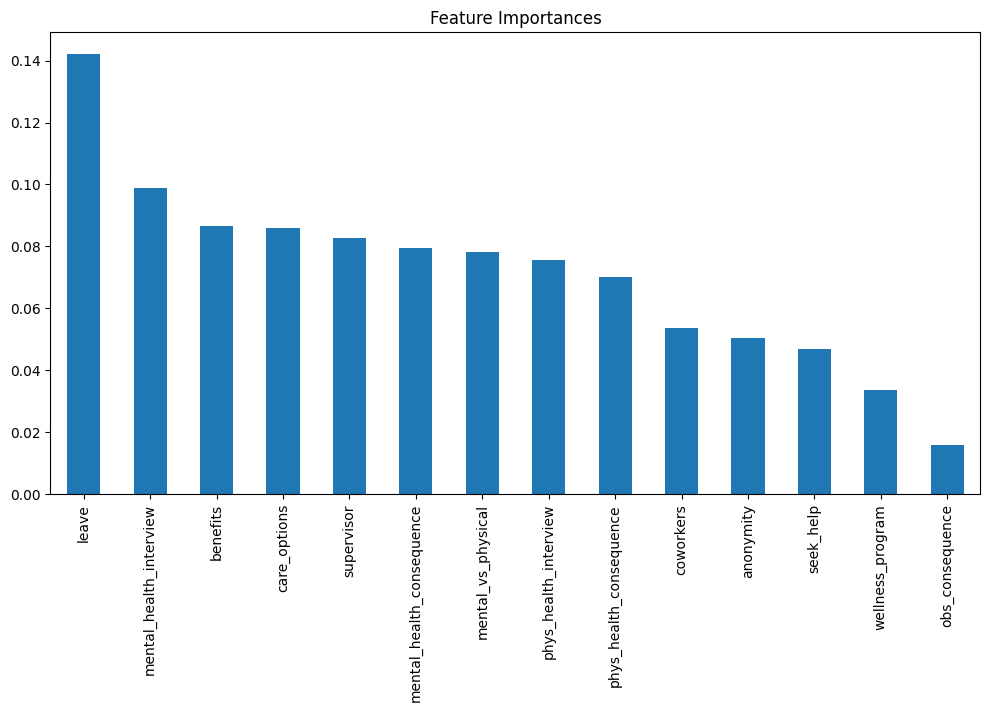

In [ ]:
# Perform clustering for k = 7
kmeans = KMeans(n_clusters=7, random_state=0, n_init="auto")
country_cluster_data['Cluster'] = kmeans.fit_predict(country_cluster_data[openness_features])

# Map clusters for model data
country_cluster_map = country_cluster_data.set_index('Country_name')['Cluster'].to_dict()
openness_model_data['Country_cluster_k7'] = openness_model_data['Country_name'].map(country_cluster_map)

# Developing Decision Tree predictor model with balancing class weight
new_rf_opennes_cv = RandomForestClassifier(random_state=42, class_weight='balanced')

# Using Stratified k fold for cross validation with 10 fold
new_skf_openness = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Calculating cross validation scores wth stratified k fold method with 10 folds (developed for Decision Tree with cross-validation)
new_cv_scores_openness_rf = cross_val_score(new_rf_opennes_cv, openness_model_data[openness_features], openness_model_data['Country_cluster_k7'],
                                            cv=new_skf_openness, scoring='accuracy')

# Predicting values for cross validation
new_rf_openness_cv_predict = cross_val_predict(new_rf_opennes_cv, openness_model_data[openness_features], openness_model_data['Country_cluster_k7'],
                                               cv=new_skf_openness)

#evaluating the outcome - cross_validation
print(f"Cross-validation accuracy scores: {new_cv_scores_openness_rf}")
print(f"Mean accuracy: {new_cv_scores_openness_rf.mean():.4f}")
print(f"Standard deviation: {new_cv_scores_openness_rf.std():.4f}")

# Create confusion matrix
new_cm_cv_op_rf = confusion_matrix(openness_model_data['Country_cluster_k7'], new_rf_openness_cv_predict)

new_disp_cv_op_rf = ConfusionMatrixDisplay(confusion_matrix=new_cm_cv_op_rf)
new_disp_cv_op_rf.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (cross-validation)')
plt.show()

# Generate classification report
new_report_cv_op_rf = classification_report(openness_model_data['Country_cluster_k7'], new_rf_openness_cv_predict)
print("Classification Report (cross-validation):\n", new_report_cv_op_rf)

new_rf_opennes_cv.fit(openness_model_data[openness_features], openness_model_data['Country_cluster_k7'])
#Feature importance cross validation
new_feat_importances_op_rf_cv = pd.Series(new_rf_opennes_cv.feature_importances_, index=openness_features)
new_feat_importances_op_rf_cv = new_feat_importances_op_rf_cv.sort_values(ascending=False)
# plot feature importances
new_feat_importances_op_rf_cv.plot(kind='bar', figsize=(12,6), title='Feature Importances')
plt.show()


A significan increase of accuracy (0.91) is observed. Also precision for clusters 1 (0.67), 3 (0.92) and 5 (0.31) looks very good. This result could be obtained since clusters were made based on mean of each feature per country. Clustering algorythm chose countries with similar feature means and put them in one cluster. Therefore countries with similar patters were found and grouped. Unfortunalety still some of the clusters are predicted with 0 precision. Looking at distribution of countries in clusters can explain this.  
Features that are the most significant (over 0.8 treshold) are: possibility to take medical leave for mental health condition (leave), probability of bringing up mental health during interview with potential employer (mental_health_interview), mental health benefits offered by employer (benefits), awareness of mental health care options provided by employer (care_options) and wheather respondets talk about mental health with their supervisor (supervisor).  

Country_cluster_k7
3    1146
5      86
4       6
1       5
0       4
2       3
6       1
Name: count, dtype: int64


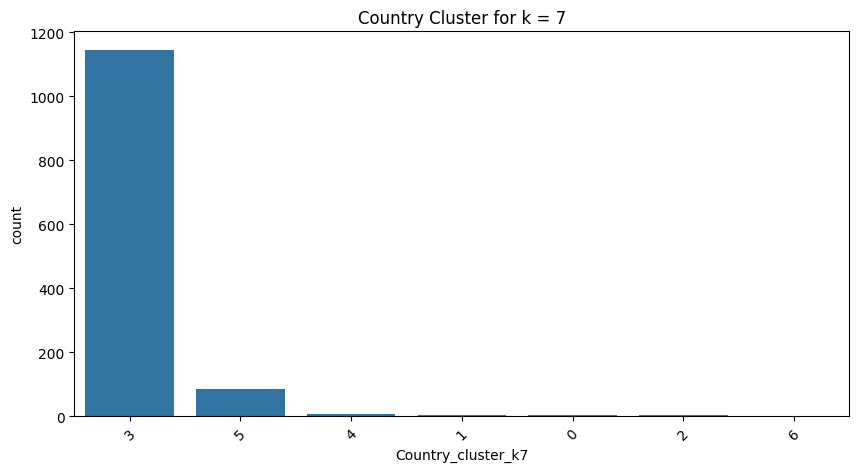

,Cluster,Country_name
25,0,Mexico
42,0,Thailand
12,1,Denmark
7,1,China
26,1,Moldova
11,1,Czech Republic
37,2,Slovenia
30,2,Norway
45,2,Uruguay
6,3,Canada


In [ ]:
# Show countries in clusters
print(openness_model_data['Country_cluster_k7'].value_counts())

# Draw plot of new category Country_cluster
plt.figure(figsize=(10,5))
counts = openness_model_data['Country_cluster_k7'].value_counts()
sns.countplot(data=df, x=openness_model_data['Country_cluster_k7'], order=counts.index)
plt.title('Country Cluster for k = 7')
plt.xticks(rotation=45)
plt.show()

country_cluster_data[['Cluster', 'Country_name']].sort_values('Cluster')

Again distribution of countries in clusters is not balanced with clusters 3 and 5 having advantage over other clusters. This could explain high precision of model prediction for those clusters.

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Cross-validation accuracy scores: [0.66666667 0.744      0.656      0.704      0.76       0.736
 0.664      0.688      0.688      0.768     ]
Mean accuracy: 0.7075
Standard deviation: 0.0394


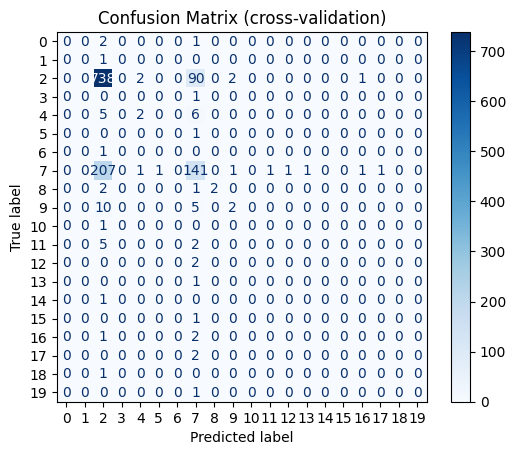

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report (cross-validation):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.76      0.89      0.82       833
           3       0.00      0.00      0.00         1
           4       0.40      0.15      0.22        13
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         1
           7       0.55      0.40      0.46       356
           8       1.00      0.40      0.57         5
           9       0.40      0.12      0.18        17
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         7
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         1
          16       0.00      0.00     

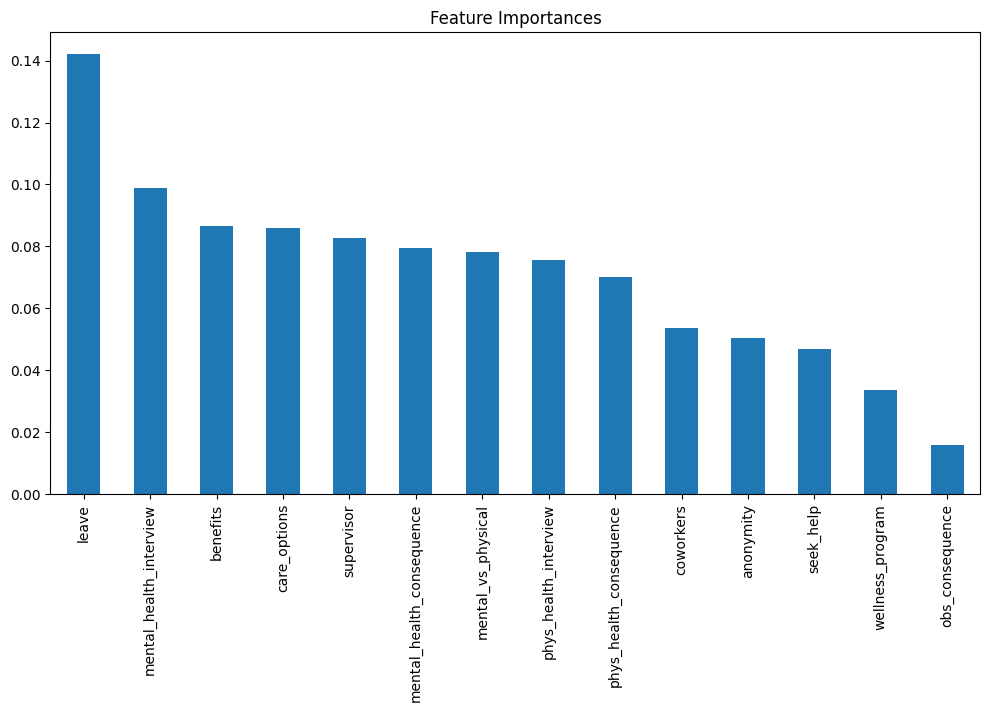

In [ ]:
# Perform clustering for k = 20
kmeans = KMeans(n_clusters=20, random_state=0, n_init="auto")
country_cluster_data['Cluster'] = kmeans.fit_predict(country_cluster_data[openness_features])

# Map clusters for model data
country_cluster_map = country_cluster_data.set_index('Country_name')['Cluster'].to_dict()
openness_model_data['Country_cluster_k20'] = openness_model_data['Country_name'].map(country_cluster_map)

# Developing Decision Tree predictor model with balancing class weight
new_rf_opennes_cv = RandomForestClassifier(random_state=42, class_weight='balanced')

# Using Stratified k fold for cross validation with 10 fold
new_skf_openness = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Calculating cross validation scores wth stratified k fold method with 10 folds (developed for Decision Tree with cross-validation)
new_cv_scores_openness_rf = cross_val_score(new_rf_opennes_cv, openness_model_data[openness_features], openness_model_data['Country_cluster_k20'],
                                            cv=new_skf_openness, scoring='accuracy')

# Predicting values for cross validation
new_rf_openness_cv_predict = cross_val_predict(new_rf_opennes_cv, openness_model_data[openness_features], openness_model_data['Country_cluster_k20'], cv=new_skf_openness)

#evaluating the outcome - cross_validation
print(f"Cross-validation accuracy scores: {new_cv_scores_openness_rf}")
print(f"Mean accuracy: {new_cv_scores_openness_rf.mean():.4f}")
print(f"Standard deviation: {new_cv_scores_openness_rf.std():.4f}")

# Create confusion matrix
new_cm_cv_op_rf = confusion_matrix(openness_model_data['Country_cluster_k20'], new_rf_openness_cv_predict)

new_disp_cv_op_rf = ConfusionMatrixDisplay(confusion_matrix=new_cm_cv_op_rf)
new_disp_cv_op_rf.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (cross-validation)')
plt.show()

# Generate classification report
new_report_cv_op_rf = classification_report(openness_model_data['Country_cluster_k20'], new_rf_openness_cv_predict)
print("Classification Report (cross-validation):\n", new_report_cv_op_rf)

new_rf_opennes_cv.fit(openness_model_data[openness_features], openness_model_data['Country_cluster_k7'])
#Feature importance cross validation
new_feat_importances_op_rf_cv = pd.Series(new_rf_opennes_cv.feature_importances_, index=openness_features)
new_feat_importances_op_rf_cv = new_feat_importances_op_rf_cv.sort_values(ascending=False)
# plot feature importances
new_feat_importances_op_rf_cv.plot(kind='bar', figsize=(12,6), title='Feature Importances')
plt.show()

Accuracy for Random Forest with cross-validation and k-means clustering where k is 20 is lower than for k = 7 being only 0.7. Precision of model prediction is only visible for clusters: 2 (0.76), 4 (0,4), 7 (0,55), 8 (1) and 9 (0,4). Again looking up distribution of countries for each cluster could ecplain precision results.
Features that are the most significant (over 0.8 treshold) are: possibility to take medical leave for mental health condition (leave), probability of bringing up mental health during interview with potential employer (mental_health_interview), mental health benefits offered by employer (benefits), awareness of mental health care options provided by employer (care_options) and wheather respondets talk about mental health with their supervisor (supervisor).  

Country_cluster_k20
2     833
7     356
9      17
4      13
11      7
8       5
16      3
0       3
17      2
12      2
15      1
19      1
10      1
5       1
13      1
6       1
18      1
1       1
3       1
14      1
Name: count, dtype: int64


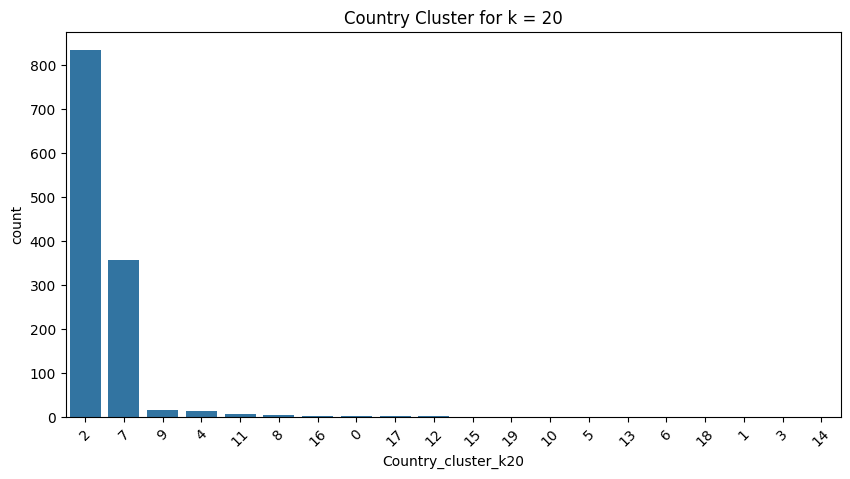

,Cluster,Country_name
25,0,Mexico
26,1,Moldova
1,2,Austria
6,2,Canada
30,2,Norway
44,2,United States
40,2,Sweden
36,2,Singapore
15,3,Georgia
38,4,South Africa


In [ ]:
# Show countries in clusters
print(openness_model_data['Country_cluster_k20'].value_counts().sort_values(ascending=False))

# Draw plot of new category Country_cluster
plt.figure(figsize=(10,5))
counts = openness_model_data['Country_cluster_k20'].value_counts()
sns.countplot(data=df, x=openness_model_data['Country_cluster_k20'], order=counts.index)
plt.title('Country Cluster for k = 20')
plt.xticks(rotation=45)
plt.show()

country_cluster_data[['Cluster', 'Country_name']].sort_values('Cluster')

As expected, clusters with most countries and most number of entries have more precision.

#### Conclusion for Model Development for country-level differences:
Model with highiest accuracy is Random Forest with cross validation (10-fold) and for clustered data (k-means algorythm) with 7 clusters.  
For this model 3 most important features were: possibility to take medical leave for mental health condition (leave), probability of bringing up mental health during interview with potential employer (mental_health_interview) and mental health benefits offered by employer (benefits).  

#### Chi-square test for country-level differences in openness to mental health issues
In order to find significant patterns for countries Chi-square test will be performed. It will tell u which features significantly differ across the countries.  

Since for chi-square test a class of attribute must have at least 5 entries Country-class grouping of countries will be used. Country_class attribute is grouping countries by their geographical localization (by continents) and class with the least members being 8 is African_countries class.

In [ ]:
print(df['Country_class'].value_counts())

Country_class
United States         746
EU_countries          358
Au_NZ_Am_countries    113
Asian_countries        26
African_countries       8
Name: count, dtype: int64


In [ ]:
from scipy.stats import chi2_contingency
# significance level
alpha = 0.05
# iteration through every significant feature
for feature in openness_features:
    # contingency table for Country_class and one feature
    contingency_table = pd.crosstab(df['Country_class'], df[feature])
    # chi-square test
    stat, p, dof, _ = chi2_contingency(contingency_table, correction=True)
    # results of test - print only significant results
    if p < alpha:
        print('Significant difference for feature ', feature, ' with p value = ', p)

Significant difference for feature  benefits  with p value =  4.120805021134832e-50
Significant difference for feature  care_options  with p value =  4.74513489677698e-13
Significant difference for feature  wellness_program  with p value =  8.596047401520895e-07
Significant difference for feature  seek_help  with p value =  4.741455154725557e-19
Significant difference for feature  anonymity  with p value =  5.063069965895987e-05
Significant difference for feature  leave  with p value =  0.0004182421689695183
Significant difference for feature  mental_health_interview  with p value =  4.8529099498834935e-05
Significant difference for feature  phys_health_interview  with p value =  4.141567196955427e-06
Significant difference for feature  obs_consequence  with p value =  0.004537094659412905


Nine features that are significant considering p-value being greater than 0.05 are found. Those features with their p-value are: benefits (4.12e-50), care_options (4.75e-13), wellness_program (8.6e-07), seek_help (4.74e-19), anonymity (5.06e-05), leave (4.18e-04), mental_health_interview (4.85e-05), phys_health_interview (4.14e-06), obs_consequence (4.54e-03). During model development when looking for most important fetures only care_options, benefits, leave, mental_health_interview and phys_health interview were also mentioned. Additionally supervisor, coworkers and mental_vs_physical features were also taken into account.  

3 most significant features are: benefits, seek_help, care_options and features that were also important for models are: mental_health_interview, phys_health_interview and leave, therefore those feature will be further explored by post-hoc chi-square pairwise test.

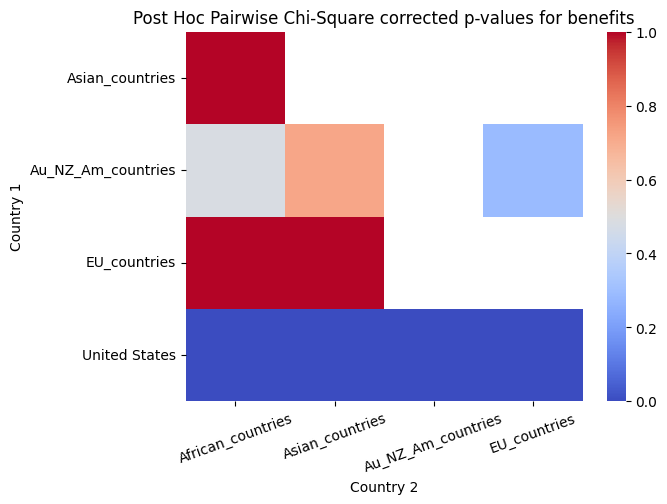

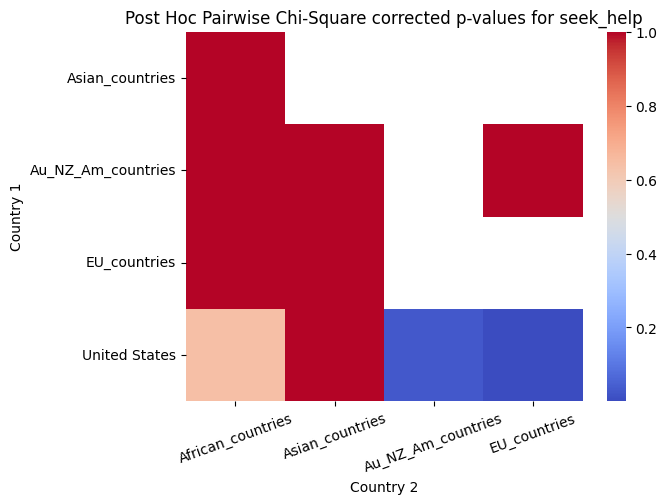

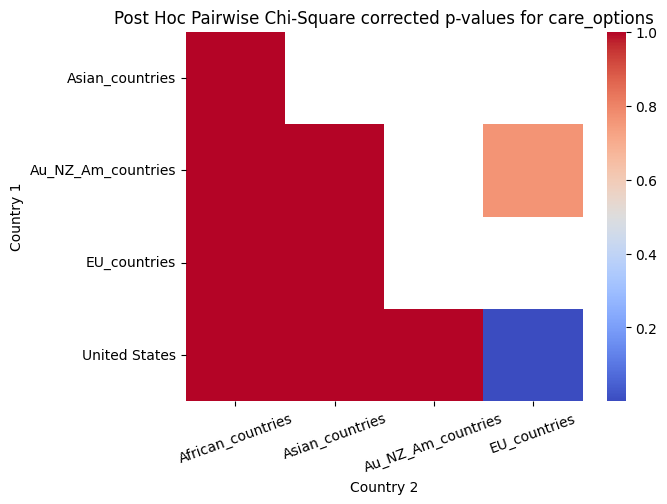

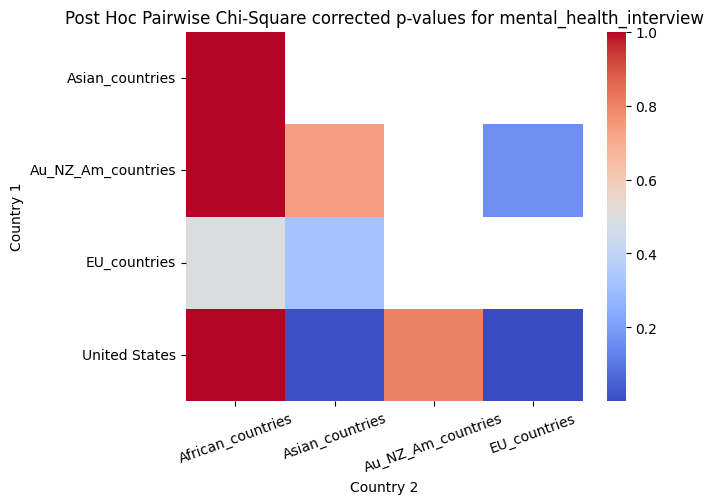

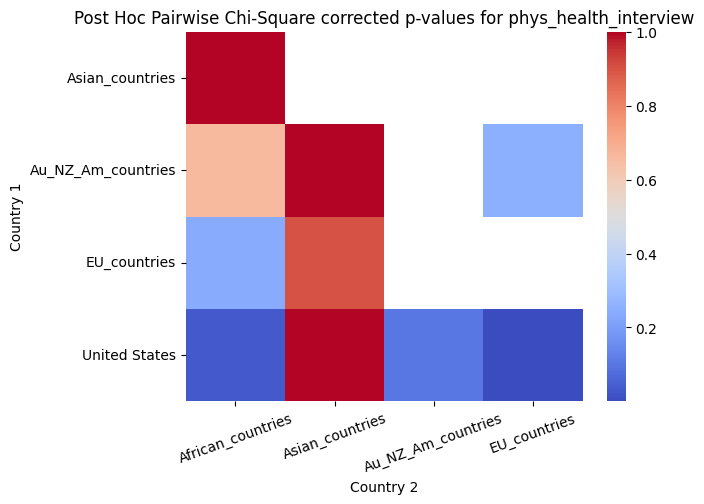

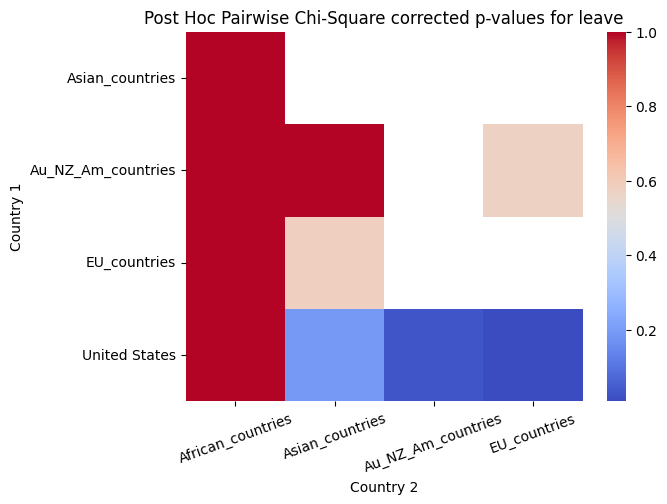

In [ ]:
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# preparer list of all countries class pairs
country_class_combinations = list(combinations(df['Country_class'].unique(), 2))
# list of all features to investigate
significant_feat = ['benefits', 'seek_help', 'care_options', 'mental_health_interview', 'phys_health_interview', 'leave']

# iterate through all features
for feat in significant_feat:
    p_vals = []
    # perform chi-square test for each pair
    for c1, c2 in country_class_combinations:
        sub_df = df[df['Country_class'].isin([c1, c2])]
        pairwise_contingency_tab = pd.crosstab(sub_df['Country'], sub_df[feat])
        stat, p, dof, freq = chi2_contingency(pairwise_contingency_tab, correction=True)
        p_vals.append(p)
    # since multiple comparisons were made - correction needs to be performed
    _, bon_correction, _, _ = multipletests(p_vals, alpha=alpha, method='bonferroni')
    # save results
    results = pd.DataFrame({'Country 1': [c[0] for c in country_class_combinations],
                            'Country 2': [c[1] for c in country_class_combinations],
                            'p_value': p_vals,
                            'corrected_p': bon_correction})
    # Heat map preparation
    pivot_tab = results.pivot(index='Country 1', columns='Country 2', values='corrected_p')
    sns.heatmap(pivot_tab, cmap='coolwarm')
    plt.title(f'Post Hoc Pairwise Chi-Square corrected p-values for {feat}')
    plt.xticks(rotation=20)
    plt.show()

The most common differeces are seen between USA and European Countries in all features. This could be due to the differences in health organizations and insurance models in both country classes. In Europe people have access to National Health Fund which in Poland is mostly free. Therefore companies don't have to provide additional health benefits. In USA healthcare is mostly privatized and employers often offer some health care options.  
Visible difference is also between group of Australia, New Zealand and American countries vs European countries when it comes to benefits, mental_health_interview and phys_health_interview attributes.  
When it comes to benefits there is significant difference comapring for USA and all other classes. Seek_help feature shows significant diference only between USA vs Australia, New Zealand, American countries and European countries. Care_options attribute is significant wih painr USA-Eurpoean countries and leave attribute shows significance when USA is compared with Asian countries, Australia, New Zealand, American countries and European countries. Mental_health interview feature is most significant for pairs USA vs Asian and Eurpoean countries, worth mentioning is also pair Australia, New Zealand and American countries vs European countries. Phys_health_interview attribute shows most significance within USA vs African countries, Australia, New Zealand and American countries, European countries.